# Analysing alpha-values over different seeds

This notebook is used to gain insights into how varying alpha values changes the dynamics of the problem and influences decision making

It is structured as follows:
1) Initial setup, imports and loading of data
2) Demand patterns and state insight
3) Trip requests
3) Failed events hourly patterns
4) Vehicle activity decision insights and time allocation
5) Comparison of alpha values



# 1 Initial setup, imports and loading of data

Her endrer du current path og seed path, disse er for rough values og fine tuning av verdier

Du kan sette alpha value, som avgjør hvilke filer den henter inn

Selection mode tilsier hvordan du lnsker å laste inn resultatene, som enkelt, average eller alle seeds

### Imports

In [552]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip
import json
import folium
import numpy as np
import matplotlib.ticker as ticker
import re
from pathlib import Path


### Loading files

In [553]:


# --- 1. ROBUST RELATIVE PATH SETUP ---

def find_project_root(start_path: Path) -> Path:
    """
    Searches up the directory tree to find the project root 
    by looking for the 'instances' folder.
    """
    # Check current folder and all parents
    for parent in [start_path] + list(start_path.parents):
        if (parent / "instances").exists():
            return parent
    
    # Fallback: Just return the current working directory if not found
    print("Warning: Could not auto-detect project root (looking for 'instances' folder). Using CWD.")
    return start_path

# 1. Detect Root
project_root = find_project_root(Path.cwd())
print(f"Project Root detected at: {project_root}")

# 2. Define Experiment Settings
policy_name = "sjovik_sund"
experiment_folder = "final_tuning"  # e.g., "final_tuning" or "N_rough_results"

# 3. Construct Paths Relative to Root
results_dir_root = project_root / "policies" / policy_name / "simulation_results" / experiment_folder
instance_path = project_root / "instances" / "TD_W34_old.json.gz"

# (Optional) Verify paths exist to help debug
if not results_dir_root.exists():
    print(f"CRITICAL WARNING: Results directory not found at: {results_dir_root}")
if not instance_path.exists():
    print(f"CRITICAL WARNING: Instance file not found at: {instance_path}")


# --- 2. CONFIGURATION ---
alpha_value = 0.26
alpha_str = f"{alpha_value:.3f}"

# SELECT MODE HERE: specific integer (e.g., 1, 3), "average", or "all"
selection_mode = "all"

CAP_AT_DAY_4 = True

# --- HELPER FUNCTIONS ---

def get_result_file(kind: str, seed: int) -> Path:
    """Finds the specific file for a given kind and seed."""
    pattern = f"*fullweek_{alpha_str}_results_{kind}_seed_{seed}.csv"
    matches = list(results_dir_root.glob(pattern))
    
    if not matches:
        raise FileNotFoundError(f"No file found matching pattern: {pattern}\nIn folder: {results_dir_root}")
    return matches[0]

def get_available_seeds(alpha_s: str) -> list[int]:
    """Scans the folder to find all seed numbers for the given alpha."""
    pattern = f"*fullweek_{alpha_s}_results_hourly_seed_*.csv"
    matches = list(results_dir_root.glob(pattern))
    
    seeds = []
    for p in matches:
        # Regex to extract the number after 'seed_'
        match = re.search(r"seed_(\d+)", p.name)
        if match:
            seeds.append(int(match.group(1)))
    return sorted(list(set(seeds)))

# ---------------------------
# 1. HELPER: TIME CAPPING (With +1 Hour buffer)
# ---------------------------
def apply_time_cap(df):
    """
    Truncates data to stop at Day 4, but includes Day 5 Hour 0 
    to ensure the plot line touches the right edge boundary.
    """
    if not CAP_AT_DAY_4:
        return df.copy()
    
    # Logic: Keep everything less than Day 5, OR exactly Day 5 Hour 0
    if "Day" in df.columns and "Hour" in df.columns:
        mask = (df["Day"] < 4) | \
               ((df["Day"] == 4) & (df["Hour"] <= 24)) | \
               ((df["Day"] == 5) & (df["Hour"] == 0))
        return df[mask].copy()
    
    # Fallback for Time (minutes)
    # 5 days * 24h * 60m = 7200 minutes
    elif "Time (minutes)" in df.columns:
        return df[df["Time (minutes)"] <= (5 * 24 * 60)].copy()
        
    return df.copy()

def load_single_seed(seed: int) -> dict:
    """Loads all 4 dataframes for a specific seed into a dictionary."""
    print(f"   -> Loading Seed {seed}...")
    return {
        "vehicle": pd.read_csv(get_result_file("vehicle_visits", seed)),
        "hourly": pd.read_csv(get_result_file("hourly", seed)),
        "station_hourly": pd.read_csv(get_result_file("station_hourly", seed)),
        "trip_requests": pd.read_csv(get_result_file("trip_requests", seed))
    }

# --- 3, 4, & 5. DYNAMIC LOADING & SELECTION LOGIC ---

# 1. Identify which seeds exist
available_seeds = get_available_seeds(alpha_str)
print(f"Found {len(available_seeds)} available seeds for alpha {alpha_str}: {available_seeds}")

if not available_seeds:
    print("ERROR: No seeds found. Check your 'results_dir_root' path.")
else:
    # Initialize container for 'all' mode
    all_seeds_data = {} 

    # Logic Switch
    if selection_mode == "all":
        print("--> Mode: Loading ALL seeds separately")
        
        for seed in available_seeds:
            all_seeds_data[seed] = load_single_seed(seed)
            
        source_label = f"All Seeds ({len(available_seeds)} total)"
        print("Data accessible via dict `all_seeds_data[seed_number]`")
        
        # Fallback for legacy scripts: expose the first seed as variables
        first_seed = available_seeds[0]
        vehicle_df = all_seeds_data[first_seed]["vehicle"]
        hourly_data = all_seeds_data[first_seed]["hourly"]
        station_hourly_activity_df = all_seeds_data[first_seed]["station_hourly"]
        trip_requests_df = all_seeds_data[first_seed]["trip_requests"]

    elif selection_mode == "average":
        print(f"--> Mode: Analyzing Average (over {len(available_seeds)} seeds)")
        
        # Temporary lists to hold dataframes for averaging/concat
        hourly_list = []
        station_hourly_list = []
        vehicle_list = []
        trip_list = []

        for seed in available_seeds:
            data = load_single_seed(seed)
            hourly_list.append(data["hourly"])
            station_hourly_list.append(data["station_hourly"])
            vehicle_list.append(data["vehicle"])
            trip_list.append(data["trip_requests"])

        # 1. Average the numeric data (Hourly)
        print("   -> Calculating averages...")
        hourly_concat = pd.concat(hourly_list)
        hourly_data = hourly_concat.groupby(hourly_concat.index).mean()
        
        # 2. Average Station Hourly
        station_concat = pd.concat(station_hourly_list)
        station_hourly_activity_df = station_concat.groupby(station_concat.index).mean()

        # 3. Concatenate Logs
        vehicle_df = pd.concat(vehicle_list, ignore_index=True)
        trip_requests_df = pd.concat(trip_list, ignore_index=True)
        
        source_label = f"Average (Seeds {min(available_seeds)}-{max(available_seeds)})"

    elif isinstance(selection_mode, int):
        print(f"--> Mode: Analyzing Specific Seed {selection_mode}")
        
        if selection_mode not in available_seeds:
            raise ValueError(f"Seed {selection_mode} not found in directory.")
            
        data = load_single_seed(selection_mode)
        
        vehicle_df = data["vehicle"]
        hourly_data = data["hourly"]
        station_hourly_activity_df = data["station_hourly"]
        trip_requests_df = data["trip_requests"]
        
        source_label = f"Seed {selection_mode}"

    else:
        raise ValueError("Invalid selection_mode. Choose an integer, 'average', or 'all'.")

    # --- 6. LOAD STATION MAP DATA ---
    with gzip.open(instance_path, "rt") as f:
        data = json.load(f)

    stations_df = pd.DataFrame(data["stations"])
    stations_df[["lat", "lon"]] = stations_df["location"].apply(pd.Series)

    print("\nProcessing Complete.")

Project Root detected at: c:\Users\Minamsj\FOMOsim
Found 2 available seeds for alpha 0.260: [1, 3]
--> Mode: Loading ALL seeds separately
   -> Loading Seed 1...
   -> Loading Seed 3...
Data accessible via dict `all_seeds_data[seed_number]`

Processing Complete.


In [554]:
# values used in the plots and analysis
plt.rcParams.update({
    'figure.figsize': (16, 8),
})

value_size = 13
font_size = 15

### Color palette

In [555]:
colors = [
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

## 1.1 State overview

### Seed 1

In [556]:
# --- 7. SUMMARY STATISTICS ---

metrics_dict = {
    "Maintenance Time (minutes)": "sum",
    "Maintenance Violations": "sum",
    "Maintenance Starvations": "sum",
    "Bike Starvations": "sum",
    "Starvations": "sum",
    "Bike Pickups": "sum",
    "Bike Deliveries": "sum",
}

print(f"\n{'='*20} SUMMARY STATISTICS (Alpha = {alpha_value}) {'='*20}")

if selection_mode == "all":
    # Create a Comparison Table
    summary_data = {}
    
    for seed_num, data_dict in all_seeds_data.items():
        # Aggregate for this specific seed
        agg = data_dict["hourly"].agg(metrics_dict)
        summary_data[f"Seed {seed_num}"] = agg
    
    # Convert dictionary to DataFrame for nice printing
    comparison_df = pd.DataFrame(summary_data)
    
    # Add a row for Mean and Std Dev to help you analyze stability
    comparison_df["Mean"] = comparison_df.mean(axis=1)
    comparison_df["StdDev"] = comparison_df.std(axis=1)
    
    print(comparison_df.round(2))

else:
    # Single or Average Mode uses the global 'hourly_data'
    alpha_summary = hourly_data.agg(metrics_dict).reset_index()
    alpha_summary.columns = ["Metric", "Value"]
    
    print(f"Mode: {selection_mode}")
    print(alpha_summary.to_string(index=False))


# --- 8. PRINT FILE PATHS USED ---
print("\n" + "="*50)
print("FILES USED:")

# Determine which seeds were actually used
if selection_mode == "all":
    seeds_to_report = available_seeds
elif selection_mode == "average":
    seeds_to_report = available_seeds
elif isinstance(selection_mode, int):
    seeds_to_report = [selection_mode]
else:
    seeds_to_report = []

for seed in seeds_to_report:
    print(f"\n--- Seed {seed} Files ---")
    try:
        print(f"Vehicle visits: {get_result_file('vehicle_visits', seed=seed)}")
        print(f"Hourly data:    {get_result_file('hourly', seed=seed)}")
        print(f"Station hourly: {get_result_file('station_hourly', seed=seed)}")
        print(f"Trip requests:  {get_result_file('trip_requests', seed=seed)}")
    except FileNotFoundError as e:
        print(f"MISSING FILES: {e}")

print("="*50)


==================== SUMMARY STATISTICS (Alpha = 0.26) ====================
                             Seed 1   Seed 3     Mean  StdDev
Maintenance Time (minutes)  1900.73  1890.39  1895.56    5.17
Maintenance Violations        63.00    77.00    70.00    7.00
Maintenance Starvations      426.00   525.00   475.50   49.50
Bike Starvations             820.00   661.00   740.50   79.50
Starvations                 1246.00  1186.00  1216.00   30.00
Bike Pickups                1154.00  1132.00  1143.00   11.00
Bike Deliveries             1136.00  1112.00  1124.00   12.00

FILES USED:

--- Seed 1 Files ---
Vehicle visits: c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\final_tuning\sjovik_sund_alphas_1112251951_TD_000125_TEST03_seed_1_alpha01-05_fullweek_0.260_results_vehicle_visits_seed_1.csv
Hourly data:    c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\final_tuning\sjovik_sund_alphas_1112251951_TD_000125_TEST03_seed_1_alpha01-05_fullweek_0.260_results_ho

# 2 Demand patterns and state insight

In [557]:
# print the instance path used
print(f"Instance used: {instance_path}")

# print number of stations, vehicles used, number of bikes
print(f"Number of vehicles in instance: {vehicle_df['Vehicle ID'].nunique()}")
print(f"Number of stations in instance: {len(stations_df)}")      


Instance used: c:\Users\Minamsj\FOMOsim\instances\TD_W34_old.json.gz
Number of vehicles in instance: 1
Number of stations in instance: 67


## 2.1 Average demand per hour for the simulation horizon

Generating demand plots for all 2 seeds...


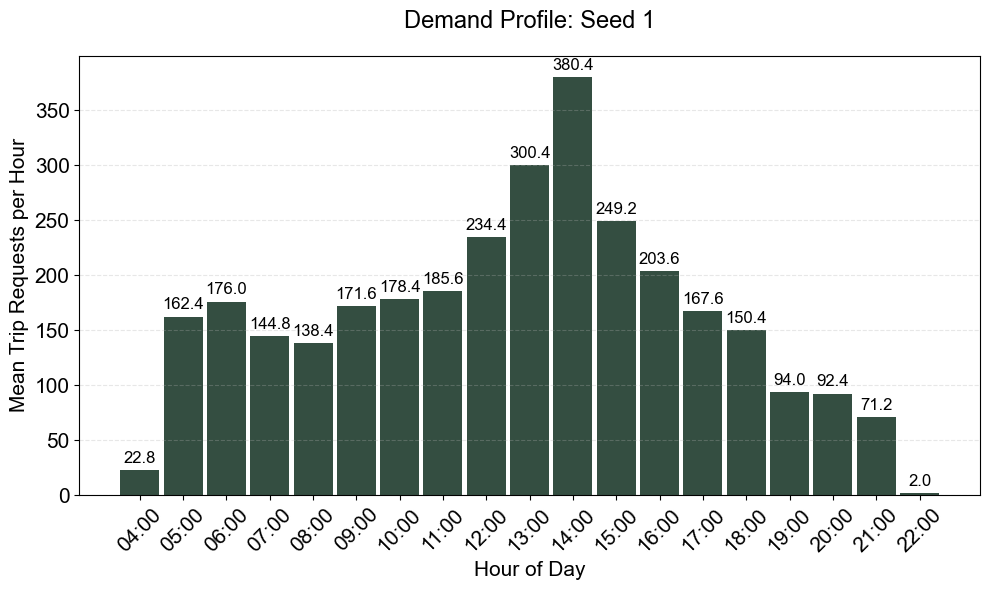

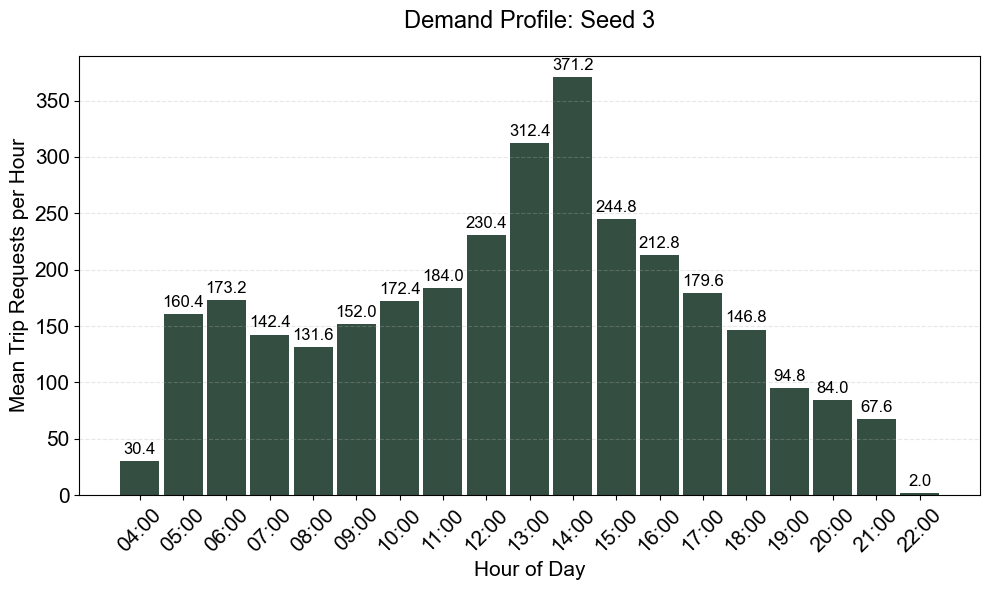

In [558]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_demand(df_requests, title_label, color_hex):
    """
    Calculates and plots the mean hourly demand for a given trip DataFrame.
    """
    # 1. Count requests for each (Day, Hour) pair
    demand_by_day_hour = (
        df_requests.groupby(["Day", "Hour"])
        .size()
        .reset_index(name="Requests")
    )

    # 2. Compute mean requests per hour across days
    mean_hourly_demand = (
        demand_by_day_hour.groupby("Hour")["Requests"]
        .mean()
        .reset_index()
    )

    hours = mean_hourly_demand["Hour"].tolist()
    demand_vals = mean_hourly_demand["Requests"].tolist()

    # Format x-axis labels as HH:00
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6)) # Explicit size for consistency
    
    # Use the passed color
    plt.bar(hour_labels, demand_vals, color=color_hex, alpha=1.0, width=0.9)

    plt.xlabel("Hour of Day", fontsize=font_size)
    plt.ylabel("Mean Trip Requests per Hour", fontsize=font_size)
    plt.title(f"Demand Profile: {title_label}", fontsize=font_size+2, pad=20)

    # Threshold for determining if bar is "too low"
    threshold = 0.10 * max(demand_vals) if demand_vals else 0

    # Label values on bars
    for h, v in zip(hour_labels, demand_vals):
        # Place label ABOVE the bar
        plt.text(h, v + threshold * 0.1,
                 f"{v:.1f}",
                 ha='center', va='bottom',
                 color='black', fontsize=value_size-1)

    plt.yticks(fontsize=font_size)
    plt.xticks(rotation=45, fontsize=font_size)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Save with unique name based on label
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"mean_trip_requests_{safe_label}.svg")

    plt.tight_layout()
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# Define styling variables if not already in context
if 'font_size' not in locals(): font_size = 14
if 'value_size' not in locals(): value_size = 12
bar_color = colors[2][1]  # Default Orange/Red

if selection_mode == "all":
    print(f"Generating demand plots for all {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        # You can vary color slightly per seed if desired, or keep uniform
        plot_hourly_demand(
            df_requests=data_dict["trip_requests"], 
            title_label=f"Seed {seed_num}", 
            color_hex=bar_color
        )

else:
    # Single or Average mode
    print(f"Generating demand plot for: {source_label}")
    plot_hourly_demand(
        df_requests=trip_requests_df, 
        title_label=source_label, 
        color_hex=bar_color
    )

## 2.2 Demand across all hours

Generating full timeline plots for 2 seeds...


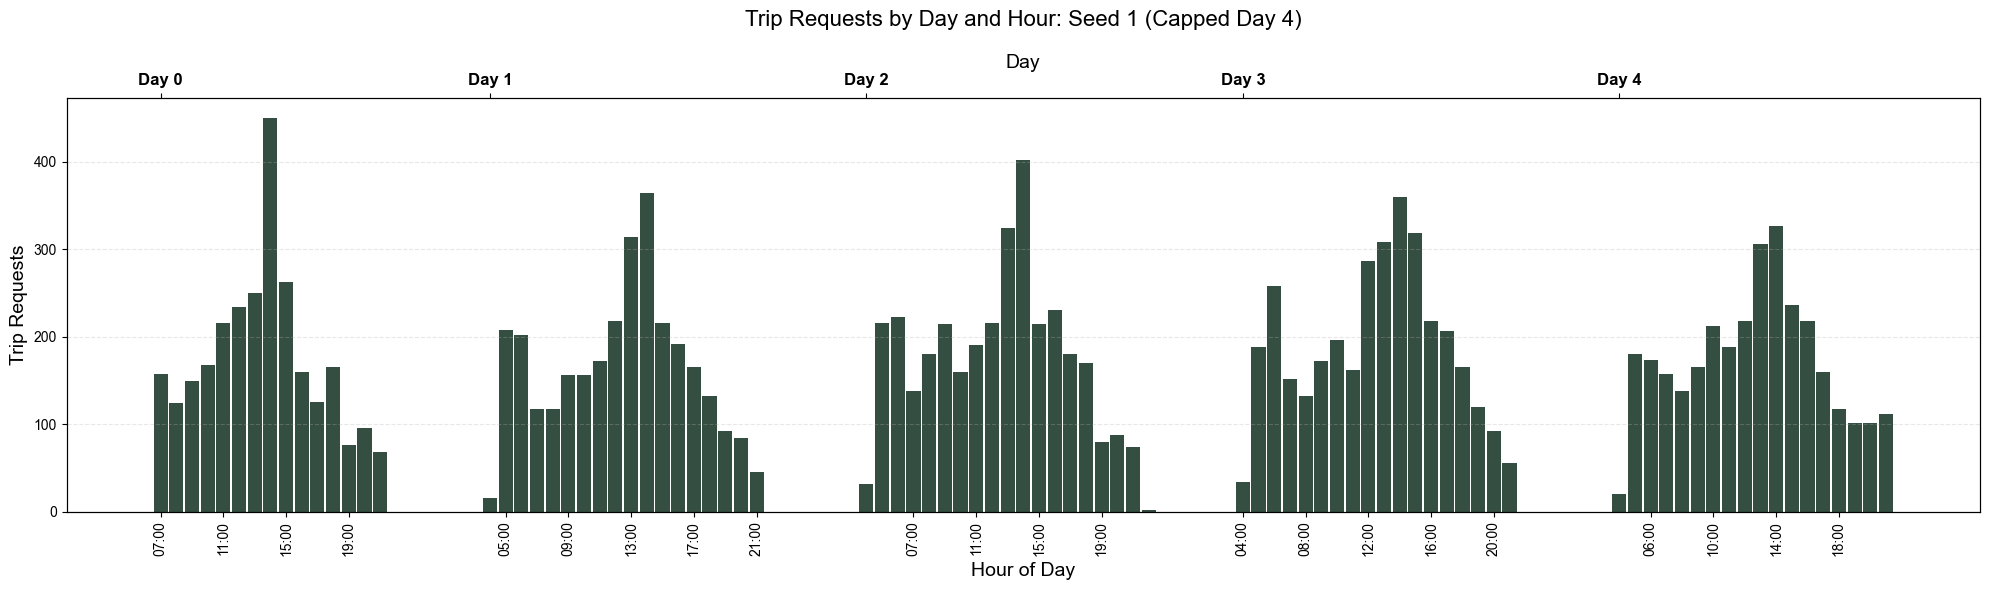

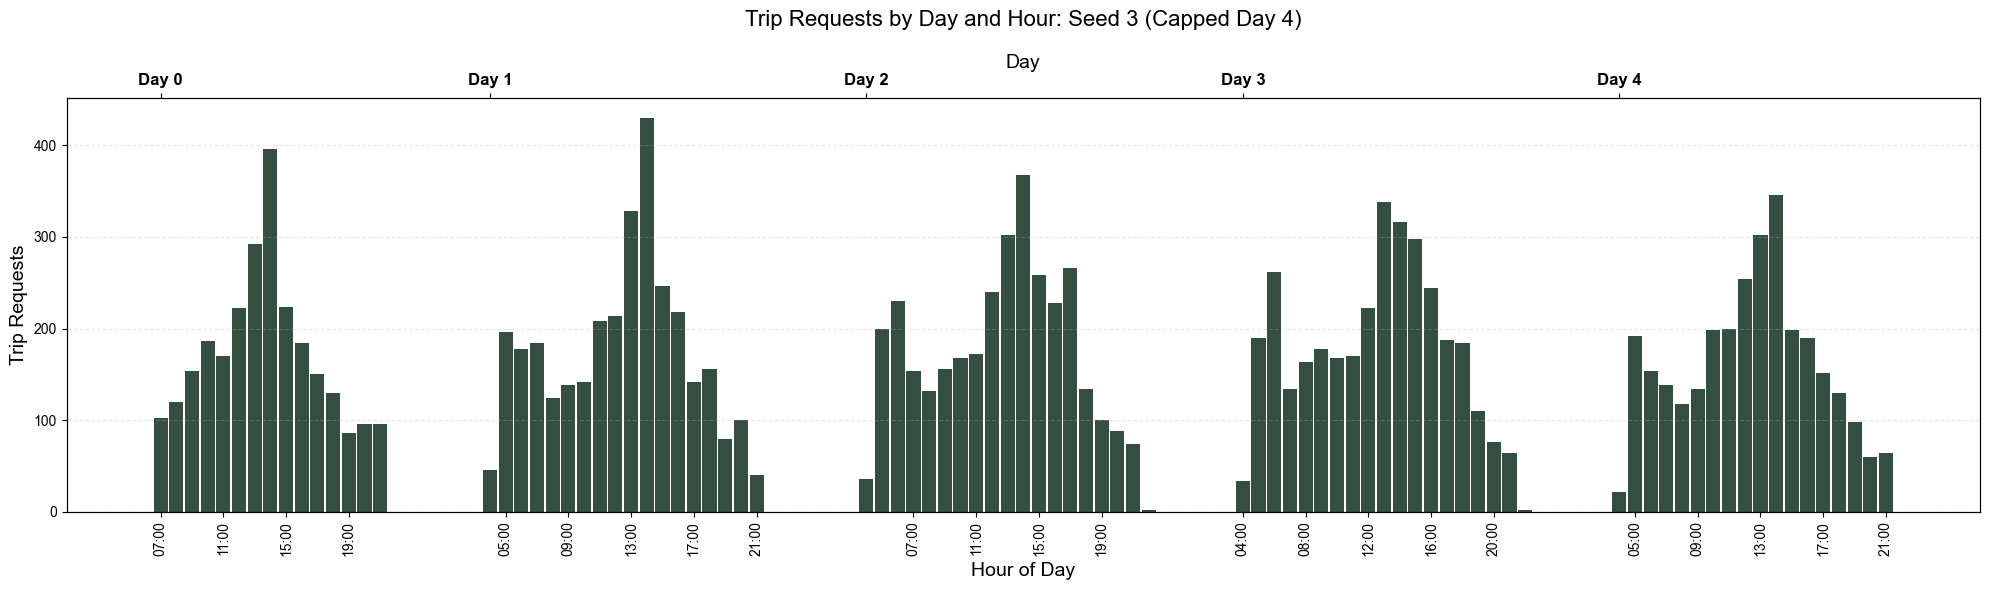

In [559]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_full_timeline(df_requests, title_label, scale_factor=1):
    """
    Plots the timeline of requests across all days.
    Applies the global CAP_AT_DAY_4 filter before plotting.
    """
    # 1. APPLY CAP
    # trip_requests_df has 'Day' and 'Hour' columns, so apply_time_cap works natively.
    df_filtered = apply_time_cap(df_requests).copy()
    
    if df_filtered.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return

    # 2. Count trip requests for each (Day, Hour) pair
    demand_by_day_hour = (
        df_filtered.groupby(["Day", "Hour"])
        .size()
        .reset_index(name="Requests")
    )

    # Normalize if this is an aggregate of multiple seeds
    if scale_factor > 1:
        demand_by_day_hour["Requests"] = demand_by_day_hour["Requests"] / scale_factor

    # Ensure sorting
    demand_by_day_hour = demand_by_day_hour.sort_values(["Day", "Hour"])

    # 3. Prepare flattened index for plotting
    # Create a unique index for each Day-Hour combination
    demand_by_day_hour["DayHourIndex"] = (
        demand_by_day_hour["Day"] * 24 + demand_by_day_hour["Hour"]
    )

    x = demand_by_day_hour["DayHourIndex"]
    y = demand_by_day_hour["Requests"]

    # Bottom x-axis label = hour (formatted)
    hour_labels = [f"{int(h):02d}:00" for h in demand_by_day_hour["Hour"]]

    # Top x-axis labels = day
    day_ticks = (
        demand_by_day_hour.groupby("Day")["DayHourIndex"]
        .min()
        .values
    )
    day_labels = [f"Day {int(d)}" for d in demand_by_day_hour["Day"].unique()]

    # 4. Plot
    fig, ax1 = plt.subplots(figsize=(20, 6))

    bar_color = colors[2][1]   # Default Orange/Red

    ax1.bar(x, y, width=0.9, color=bar_color)

    ylabel_text = "Avg Trip Requests" if scale_factor > 1 else "Trip Requests"
    ax1.set_ylabel(ylabel_text, fontsize=14)
    ax1.set_xlabel("Hour of Day", fontsize=14)

    # Bottom axis -> hours
    # Show every 4th hour if capped, or every 6th if full week to avoid crowding
    step = 4 if CAP_AT_DAY_4 else 6
    
    # Ensure step isn't larger than available data
    step = min(step, len(x)) if len(x) > 0 else 1
    
    ax1.set_xticks(list(x)[::step]) 
    ax1.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), step)], 
                        rotation=90, fontsize=10)

    # 5. Add top axis -> days
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(day_ticks)
    ax2.set_xticklabels(day_labels, fontsize=12, fontweight="bold")
    ax2.set_xlabel("Day", fontsize=14)

    # 6. Styling & Saving
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    cap_text = "(Capped Day 4)" if CAP_AT_DAY_4 else "(Full Week)"
    plt.title(f"Trip Requests by Day and Hour: {title_label} {cap_text}", fontsize=16, pad=20)
    
    safe_name = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"full_timeline_requests_{safe_name}_capped_{CAP_AT_DAY_4}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

if selection_mode == "all":
    print(f"Generating full timeline plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_full_timeline(
            df_requests=data_dict["trip_requests"],
            title_label=f"Seed {seed_num}",
            scale_factor=1 
        )

elif selection_mode == "average":
    # Trip requests stacked from all seeds
    num_seeds = len(available_seeds)
    print(f"Generating average timeline plot (normalized over {num_seeds} seeds)...")
    
    plot_full_timeline(
        df_requests=trip_requests_df,
        title_label=source_label,
        scale_factor=num_seeds 
    )

else:
    # Single specific seed
    print(f"Generating timeline plot for: {source_label}")
    plot_full_timeline(
        df_requests=trip_requests_df,
        title_label=source_label,
        scale_factor=1
    )

# 3 Trip requests and fleet aspects

## 3.1 Average fleet criticality

### 3.1.1 Line plot during the day

C:\Users\Minamsj\AppData\Local\Temp\ipykernel_19608\1288894465.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('viridis', num_seeds)


Preparing plot for 2 seeds (Capped: True)...


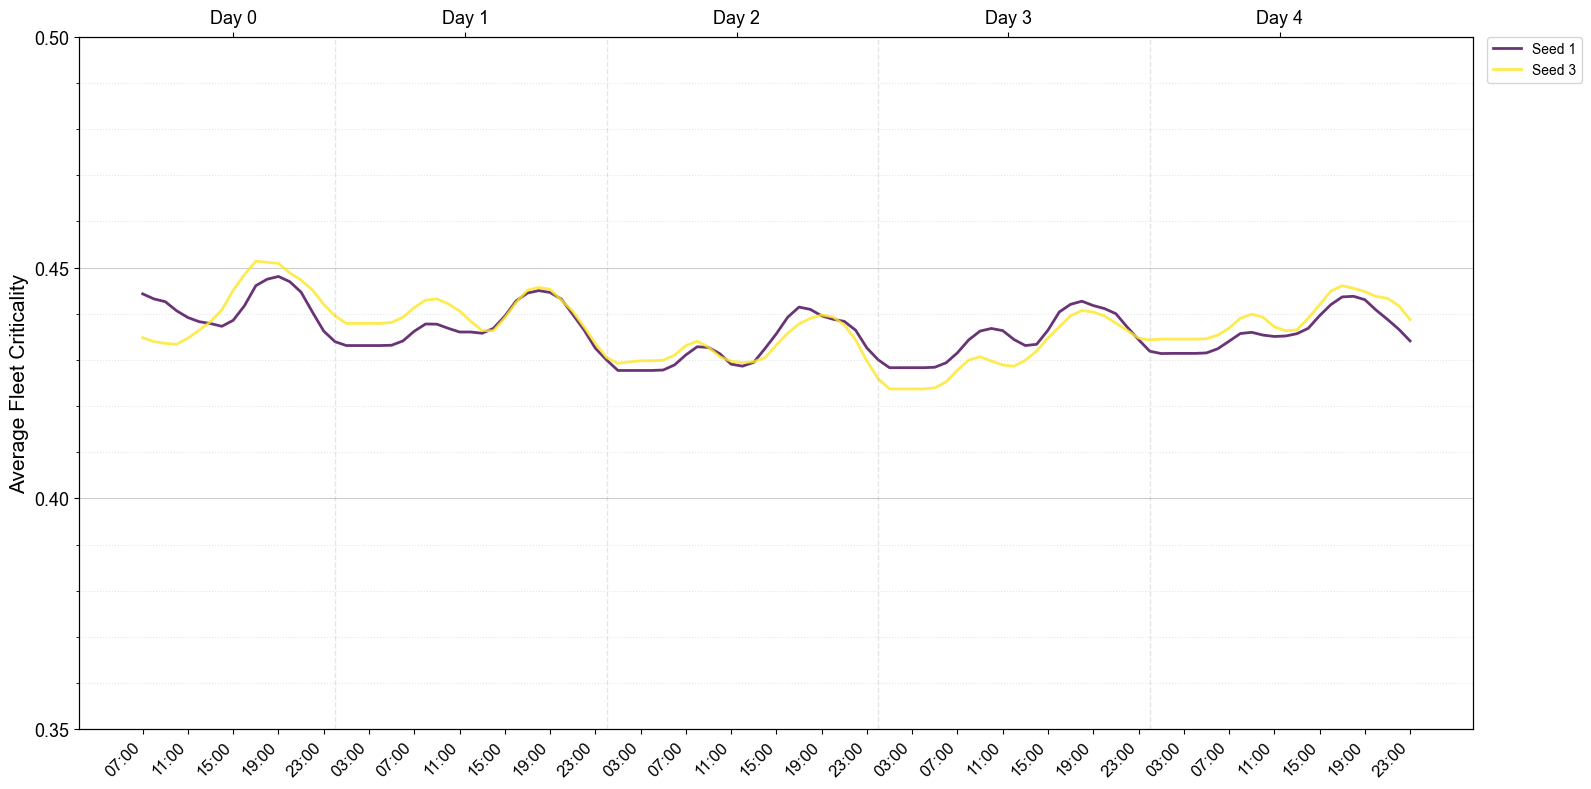

In [560]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import numpy as np

# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe and calculates the Moving Average.
    """
    # COPY and CAP the data immediately
    # (Assuming apply_time_cap is defined in your config section)
    c = apply_time_cap(df).copy()
    
    c = c[["Day", "Hour", "Avg Bike Criticality"]]
    
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
    
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)
    
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
    
    return c

# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = [] 

if selection_mode == "all":
    # --- ALL SEEDS MODE ---
    num_seeds = len(all_seeds_data)
    color_map = cm.get_cmap('viridis', num_seeds)
    print(f"Preparing plot for {num_seeds} seeds (Capped: {CAP_AT_DAY_4})...")

    for i, (seed_num, data_dict) in enumerate(all_seeds_data.items()):
        # Process the specific seed's hourly data
        processed_df = process_crit_data(data_dict["hourly"], window=window_size)
        color = color_map(i)
        plot_datasets.append((f"Seed {seed_num}", processed_df, color))
        
else:
    # --- SINGLE / AVERAGE MODE ---
    # Process the global hourly_data
    processed_df = process_crit_data(hourly_data, window=window_size)
    default_color = colors[5][1] # Blue Accent
    label_text = f"Avg Criticality ({selection_mode})"
    plot_datasets.append((label_text, processed_df, default_color))

# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")

ref_df = plot_datasets[0][1]
x_ref = ref_df.index

# Find day boundaries based on the filtered/capped data
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = day_change_idx[1:]

day_centers = []
day_labels = []
for day_val in ref_df["Day"].unique():
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)
        day_labels.append(f"Day {int(day_val)}")

# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 8))

for label, df, color in plot_datasets:
    if selection_mode == "all":
        # Plot only MA for cleaner view in 'all' mode
        ax.plot(df.index, df["MA"], linewidth=2, color=color, alpha=0.8, label=label)
    else:
        # Plot Raw + MA for single/average mode
        ax.plot(df.index, df["Avg Bike Criticality"], alpha=0.3, 
                color=color, label="_nolegend_")
        ax.plot(df.index, df["MA"], linewidth=3, 
                color=color, label=f"Moving Average ({window_size}h)")

# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)

# ---------------------------
# AXIS SETTINGS
# ---------------------------

# 1. Y-Axis Limits (As requested in your snippet)
ax.set_ylim(0.35, 0.5)

# 2. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05)) # Major every 0.05
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01)) # Minor every 0.01

# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')

ax.set_ylabel("Average Fleet Criticality", fontsize=15)
ax.set_xlabel("", fontsize=14)

# Tick frequency logic for X-axis
step = max(1, len(ref_df) // 25)
ax.set_xticks(list(x_ref)[::step])
ax.set_xticklabels(ref_df["hour_label"].iloc[::step], 
                   rotation=45, ha="right", fontsize=12)
ax.tick_params(axis='y', labelsize=13)

# ---------------------------
# 5. SECONDARY AXIS (Day Labels)
# ---------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=13)
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")

# Legend positioning
if selection_mode == "all":
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
else:
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f"average_fleet_criticality_capped_{CAP_AT_DAY_4}.svg")
plt.show()

### 3.1.2 Map showing average criticality of all stations

In [561]:

# Extract numeric station id from "S0", "S1", ...
station_hourly_activity_df["id"] = (
    station_hourly_activity_df["Station ID"]
    .astype(str)
    .str.extract(r"S(\d+)")
    .astype(int)
)

# --- Compute per-row share of capacity that is broken ---
# guard against capacity = 0 just in case
station_hourly_activity_df["broken_share"] = (
    station_hourly_activity_df["Unusable Bikes"] /
    station_hourly_activity_df["Capacity"].replace(0, np.nan)
)

# ---------------------------
# Average maintenance criticality AND avg % broken per station
# ---------------------------
crit_per_station = (
    station_hourly_activity_df
    .groupby("id", as_index=False)
    .agg(
        avg_maint_crit=("Avg Maintenance Criticality", "mean"),
        avg_broken_share=("broken_share", "mean")   # this is 0–1
    )
)

# Merge with coordinates from stations_df (must already have lat/lon)
stations_crit = stations_df.merge(crit_per_station, on="id", how="left")
stations_crit["avg_maint_crit"] = stations_crit["avg_maint_crit"].fillna(0.0)
stations_crit["avg_broken_share"] = stations_crit["avg_broken_share"].fillna(0.0)

center_lat = stations_crit["lat"].mean()
center_lon = stations_crit["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# simple color mapping based on maintenance criticality
def crit_color(c):
    if c >= 0.6:
        return "red"
    elif c >= 0.5:
        return "orange"
    elif c >= 0.4:
        return "yellow"
    else:
        return "green"

for _, row in stations_crit.iterrows():
    c = row["avg_maint_crit"]
    broken_pct = row["avg_broken_share"] * 100  # turn into %

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,  # could also scale with broken_pct if you like
        fill=True,
        fill_opacity=0.8,
        color=crit_color(c),
        fill_color=crit_color(c),
        popup=(
            f"Station S{row['id']}<br>"
            f"Avg maint. criticality: {c:.3f}<br>"
            f"Avg broken: {broken_pct:.1f}% of capacity"
        ),
    ).add_to(m)

m.save(f"station_criticality_map_S{seed}_A{alpha_value}.html")


## 3.2 Service rate computation

In [562]:
import pandas as pd

# ---------------------------
# 1. METRIC CALCULATION FUNCTION
# ---------------------------
def calculate_service_metrics(df_trips, df_hourly, scale_factor=1):
    """
    Calculates system-wide service metrics.
    
    Args:
        df_trips: DataFrame containing trip logs.
        df_hourly: DataFrame containing hourly stats (must contain 'Long Congestions').
        scale_factor: int/float. Used to normalize trip counts if df_trips contains 
                      stacked data from multiple seeds. 
                      (e.g., if Average mode over 5 seeds, scale_factor=5).
    """
    # 1. Total Requests (Normalized)
    raw_requests = len(df_trips)
    total_requests = raw_requests / scale_factor
    
    # 2. Successful Trips (Normalized)
    # A trip is successful if "Failure Reason" is NaN
    raw_successful = df_trips["Failure Reason"].isna().sum()
    total_successful = raw_successful / scale_factor
    
    # 3. Total Long Congestions
    # If df_hourly is already an 'average' dataframe, sum() gives the average weekly total.
    # If df_hourly is a single seed, sum() gives that seed's total.
    total_long_congestions = df_hourly["Long Congestions"].sum()
    
    # 4. Effective Success (Penalized by Congestion)
    # We subtract congestions from successes to account for trips that 'succeeded' 
    # but arrived at a full station (blocked).
    effective_total_successful = max(total_successful - total_long_congestions, 0)
    
    # 5. Service Rate
    service_rate = (effective_total_successful / total_requests) if total_requests > 0 else 0
    
    return {
        "Total Requests": round(total_requests, 1),
        "Successful Trips": round(total_successful, 1),
        "Long Congestions": round(total_long_congestions, 1),
        "Effective Success": round(effective_total_successful, 1),
        "Service Rate": service_rate # Keep as float for formatting later
    }

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

print(f"\n{'='*20} SERVICE LEVEL ANALYSIS {'='*20}")

if selection_mode == "all":
    # --- ALL SEEDS COMPARISON TABLE ---
    results_list = []
    
    print(f"Calculating service rates for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        metrics = calculate_service_metrics(
            df_trips=data_dict["trip_requests"],
            df_hourly=data_dict["hourly"],
            scale_factor=1 # Single seed data
        )
        
        # Add Seed ID to the dict for the table
        metrics["Seed"] = seed_num
        results_list.append(metrics)
        
    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Reorder columns to put Seed first
    cols = ["Seed", "Total Requests", "Successful Trips", "Long Congestions", "Effective Success", "Service Rate"]
    results_df = results_df[cols]
    
    # Format Service Rate as percentage string for display
    results_df["Service Rate"] = results_df["Service Rate"].apply(lambda x: f"{x:.2%}")
    
    # Print Table
    print("\n")
    print(results_df.to_string(index=False))
    
    # Optional: Print Mean Service Rate
    # Convert back to float for mean calculation
    mean_rate = results_df["Service Rate"].str.rstrip('%').astype(float).mean()
    print(f"\nAverage Service Rate across all seeds: {mean_rate:.2f}%")

else:
    # --- SINGLE OR AVERAGE MODE ---
    
    # Determine Scale Factor
    # If "average", trip_requests_df is stacked (N seeds), so we divide by N.
    # If int (single), trip_requests_df is 1 seed, so divide by 1.
    scale = len(available_seeds) if selection_mode == "average" else 1
    
    metrics = calculate_service_metrics(
        df_trips=trip_requests_df,
        df_hourly=hourly_data,
        scale_factor=scale
    )
    
    print(f"\nMode: {source_label}")
    print("-" * 30)
    print(f"Total Requests:           {metrics['Total Requests']:,.1f}")
    print(f"Successful Trips (Raw):   {metrics['Successful Trips']:,.1f}")
    print(f"Total Long Congestions:   {metrics['Long Congestions']:,.1f}")
    print("-" * 30)
    print(f"Effective Successful:     {metrics['Effective Success']:,.1f}")
    print(f"Adjusted Service Rate:    {metrics['Service Rate']:.2%}")
    print("=" * 50)


==================== SERVICE LEVEL ANALYSIS ====================
Calculating service rates for 2 seeds...


 Seed  Total Requests  Successful Trips  Long Congestions  Effective Success Service Rate
    1         15620.0           14374.0               541            13833.0       88.56%
    3         15458.0           14272.0               510            13762.0       89.03%

Average Service Rate across all seeds: 88.80%


# 4 Failed events

Generating stacked event plots for 2 seeds...


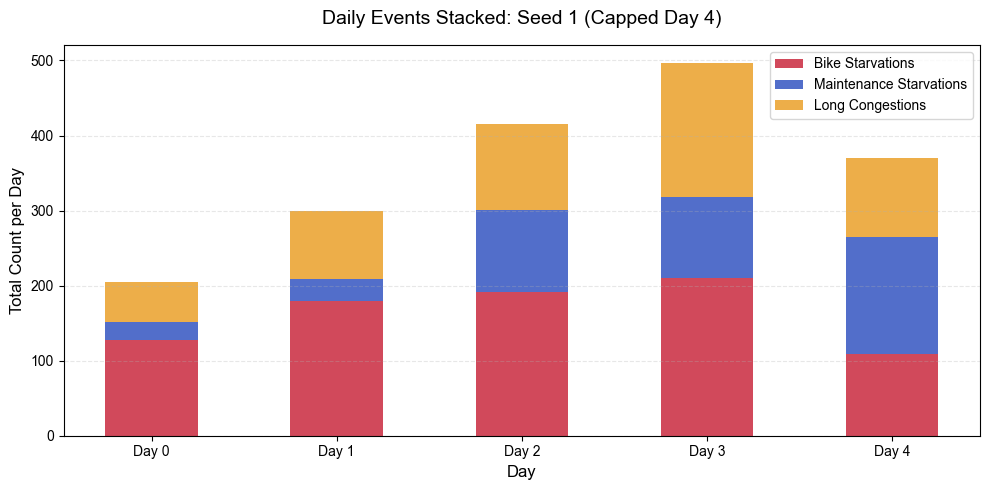

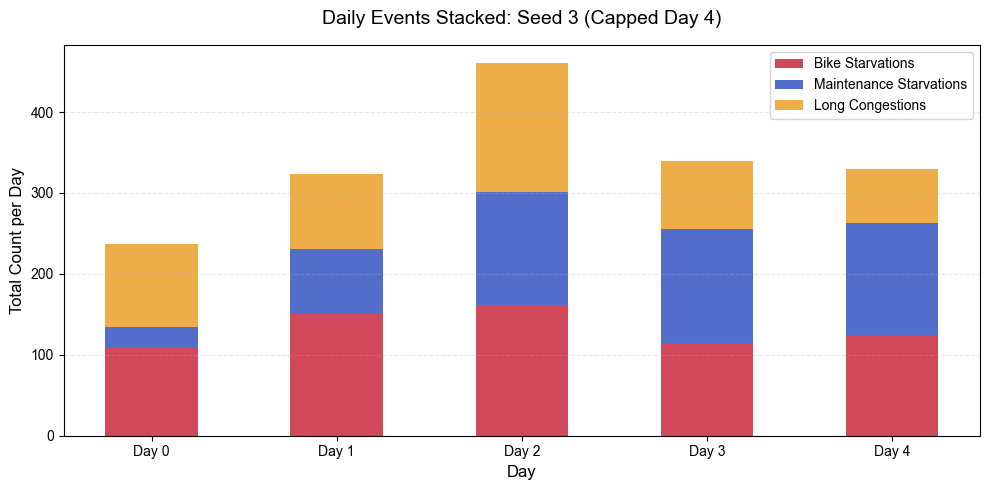

In [563]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_daily_events_stacked(df_hourly, title_label):
    """
    Aggregates hourly data by Day and plots a STACKED bar chart
    for Starvations and Congestions.
    Applies global CAP_AT_DAY_4 filter.
    """
    # 1. APPLY CAP
    df_filtered = apply_time_cap(df_hourly).copy()
    
    if df_filtered.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return

    # 2. Group by Day to get daily totals
    # We sum the metrics for each day
    daily = (
        df_filtered.groupby("Day")
        .agg({
            "Bike Starvations": "sum",
            "Maintenance Starvations": "sum",
            "Long Congestions": "sum",
            # "Short Congestions": "sum" # Add if you want to include short ones
        })
        .reset_index()
    )

    # 3. Prepare Data for Plotting
    days = daily["Day"].values
    
    # Values for stacking
    bike_starv = daily["Bike Starvations"].values
    maint_starv = daily["Maintenance Starvations"].values
    congestions = daily["Long Congestions"].values 

    x = np.arange(len(days))
    width = 0.5  # Standard width for stacked bars

    # 4. Plotting
    plt.figure(figsize=(10, 5))

    # Stack 1: Bike Starvations (Bottom)
    p1 = plt.bar(x, bike_starv, width=width, 
                 label="Bike Starvations", color=colors[3][1]) # Orange/Red

    # Stack 2: Maintenance Starvations (Middle) -> Bottom = bike_starv
    p2 = plt.bar(x, maint_starv, width=width, bottom=bike_starv,
                 label="Maintenance Starvations", color=colors[5][1]) # Blue

    # Stack 3: Congestions (Top) -> Bottom = bike_starv + maint_starv
    p3 = plt.bar(x, congestions, width=width, bottom=bike_starv + maint_starv,
                 label="Long Congestions", color=colors[4][1]) # Green/Teal

    # 5. Styling
    cap_text = "(Capped Day 4)" if CAP_AT_DAY_4 else "(Full Week)"
    
    plt.xlabel("Day", fontsize=12)
    plt.ylabel("Total Count per Day", fontsize=12)
    plt.title(f"Daily Events Stacked: {title_label} {cap_text}", fontsize=14, pad=15)

    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper right')

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"daily_stacked_events_{safe_label}_capped_{CAP_AT_DAY_4}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

if selection_mode == "all":
    print(f"Generating stacked event plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_daily_events_stacked(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}"
        )

else:
    # Works for both Single Seed (int) and Average mode
    # In 'Average' mode, hourly_data is already the mean of all seeds.
    print(f"Generating stacked event plot for: {source_label}")
    
    plot_daily_events_stacked(
        df_hourly=hourly_data,
        title_label=source_label
    )

## 4.1 Bike starvation

### 4.1.1 Plot for mean over all hours of simulation horizon

Generating starvation plots for 2 seeds...


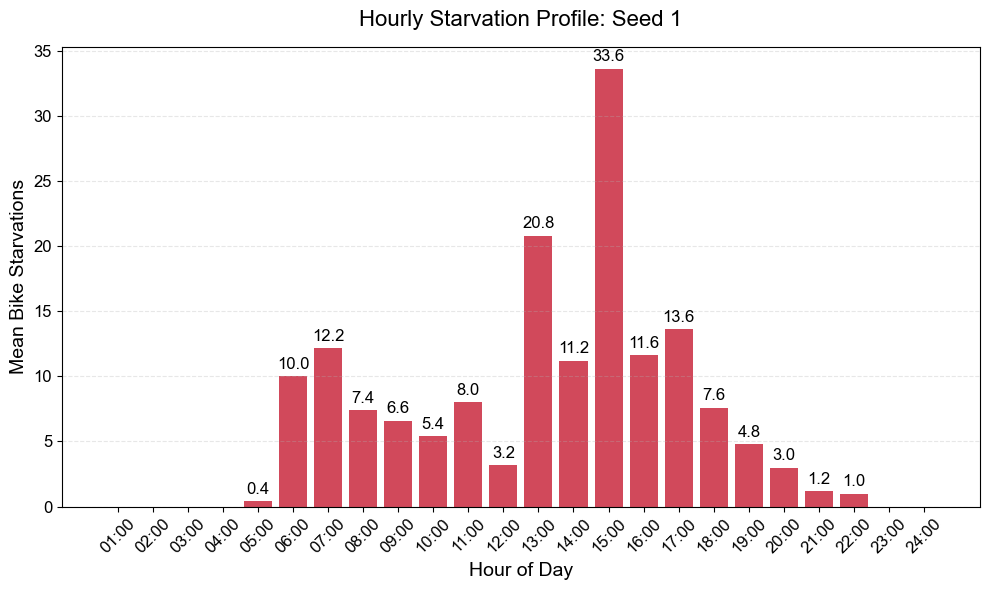

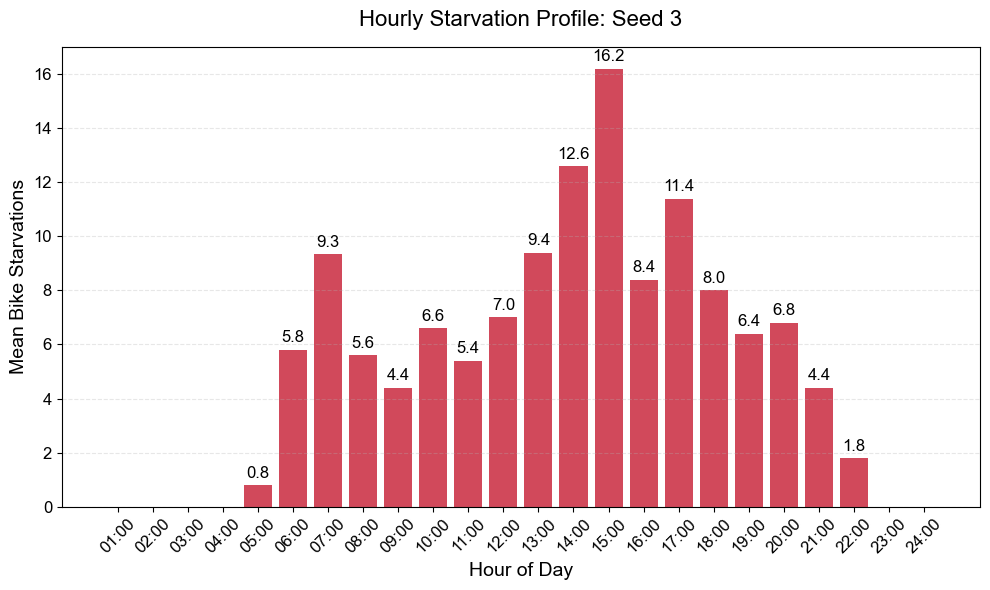

In [564]:

# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_starvations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly bike starvations.
    """
    # 1. Sum starvations for each (Day, Hour) pair within this dataset
    # (If df_hourly is averaged, this is the average sum per day)
    starv_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Bike Starvations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean starvations per hour across the simulated days
    mean_hourly_starv = (
        starv_by_day_hour.groupby("Hour")["Bike Starvations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_starv["Hour"].tolist()
    starv_vals = mean_hourly_starv["Bike Starvations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, starv_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Bike Starvations", fontsize=14)
    plt.title(f"Hourly Starvation Profile: {title_label}", fontsize=16, pad=15)

    # Handle case where max is 0 (perfect run)
    max_val = max(starv_vals) if starv_vals else 0
    threshold = 0.10 * max_val if max_val > 0 else 0

    # Label values on bars
    for h, v in zip(hour_labels, starv_vals):
        if v > 0.05: # Only label if value is significant
            plt.text(h, v + threshold * 0.1,
                     f"{v:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"mean_bike_starvations_{safe_label}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# Define styling
bar_color = colors[3][1]   # Default Red/Orange for Starvations

if selection_mode == "all":
    print(f"Generating starvation plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_hourly_starvations(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}",
            color_hex=bar_color
        )

else:
    # Single or Average Mode
    # In Average mode, hourly_data is already the mean of all seeds.
    print(f"Generating starvation plot for: {source_label}")
    
    plot_hourly_starvations(
        df_hourly=hourly_data,
        title_label=source_label,
        color_hex=bar_color
    )

## 4.2 Congestion

### 4.2.1 Plot mean over all hours of simulation horizon (24h agg)

Generating congestion plots for 2 seeds...


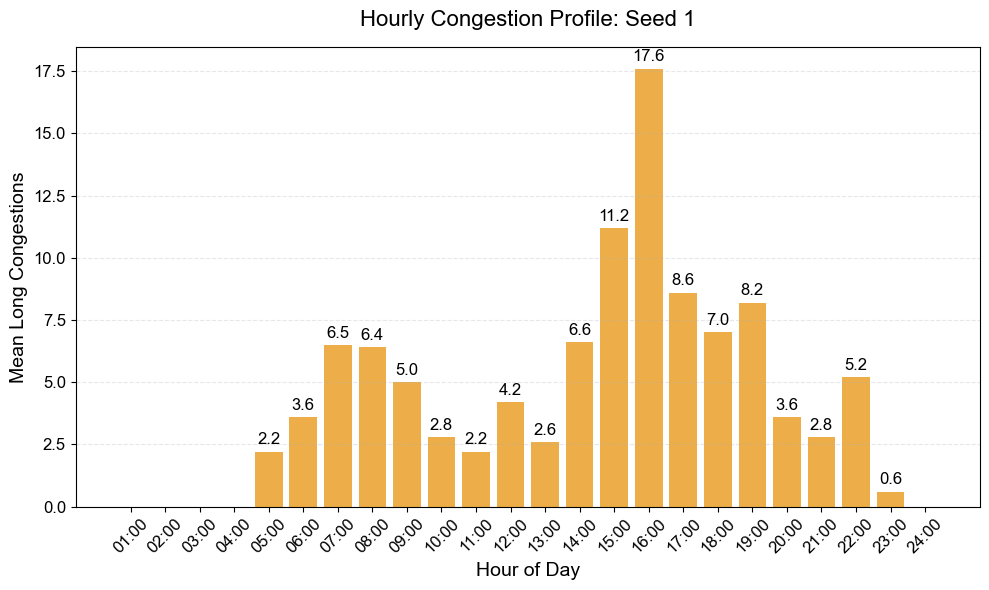

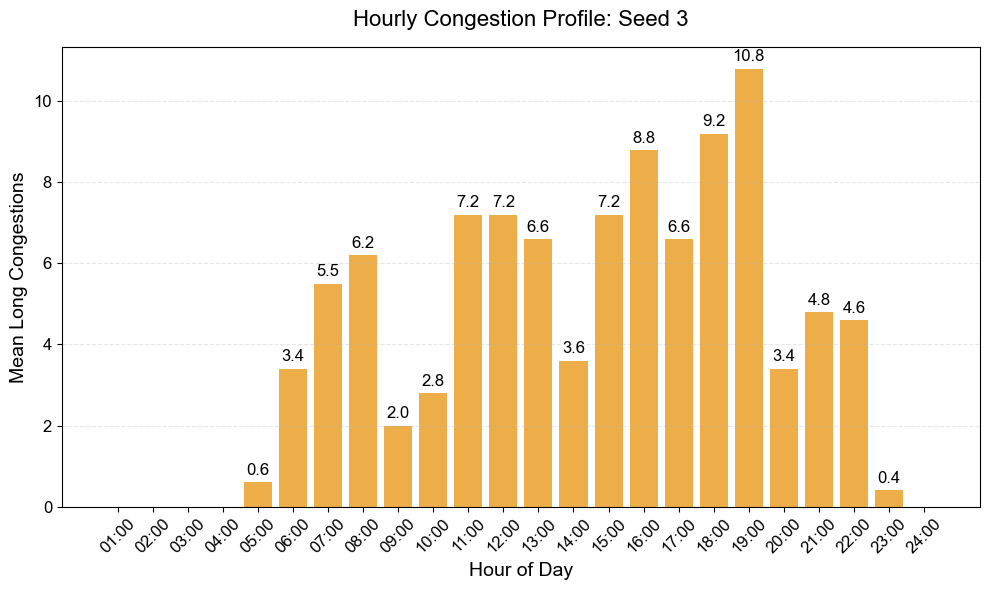

In [565]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_congestions(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly long congestions.
    """
    # 1. Sum congestions for each (Day, Hour) pair
    cong_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Long Congestions"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean congestions per hour across days
    mean_hourly_cong = (
        cong_by_day_hour.groupby("Hour")["Long Congestions"]
        .mean()
        .reset_index()
    )

    # Extract hours and mean values
    hours = mean_hourly_cong["Hour"].tolist()
    cong_vals = mean_hourly_cong["Long Congestions"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, cong_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Long Congestions", fontsize=14)
    plt.title(f"Hourly Congestion Profile: {title_label}", fontsize=16, pad=15)

    # Handle scale for label placement
    max_val = max(cong_vals) if cong_vals else 0
    threshold = 0.10 * max_val if max_val > 0 else 0

    # Label values on bars
    for h, v in zip(hour_labels, cong_vals):
        if v > 0.05: # Only label if value is non-zero/significant
            plt.text(h, v + threshold * 0.1,
                     f"{v:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"mean_long_congestions_{safe_label}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# Define styling
bar_color = colors[4][1]   # Default Green/Teal for Congestions

if selection_mode == "all":
    print(f"Generating congestion plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_hourly_congestions(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}",
            color_hex=bar_color
        )

else:
    # Single or Average Mode
    print(f"Generating congestion plot for: {source_label}")
    
    plot_hourly_congestions(
        df_hourly=hourly_data,
        title_label=source_label,
        color_hex=bar_color
    )

# 4.3 Maintenance violations

Generating maintenance violation plots for 2 seeds...


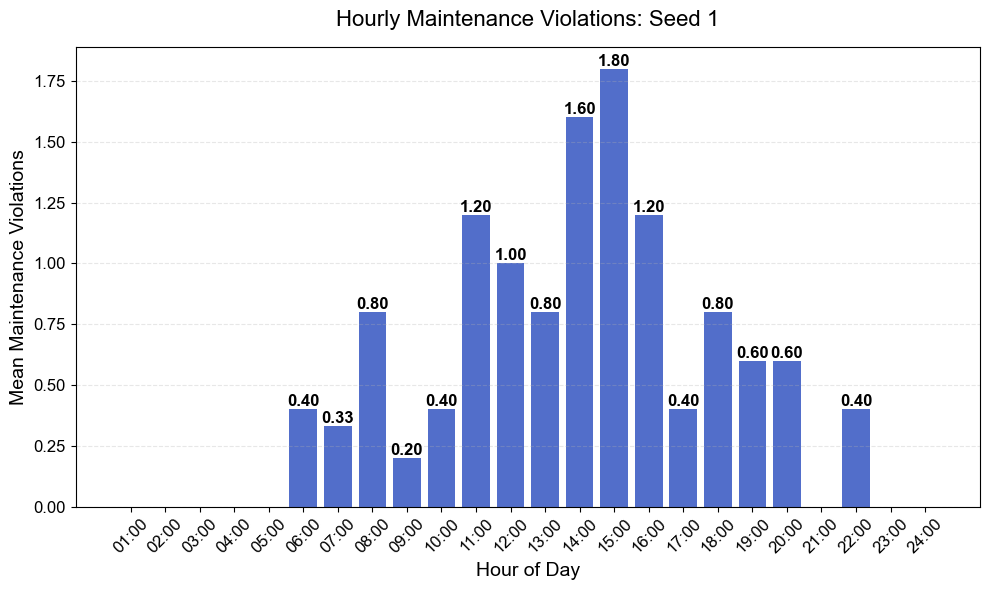

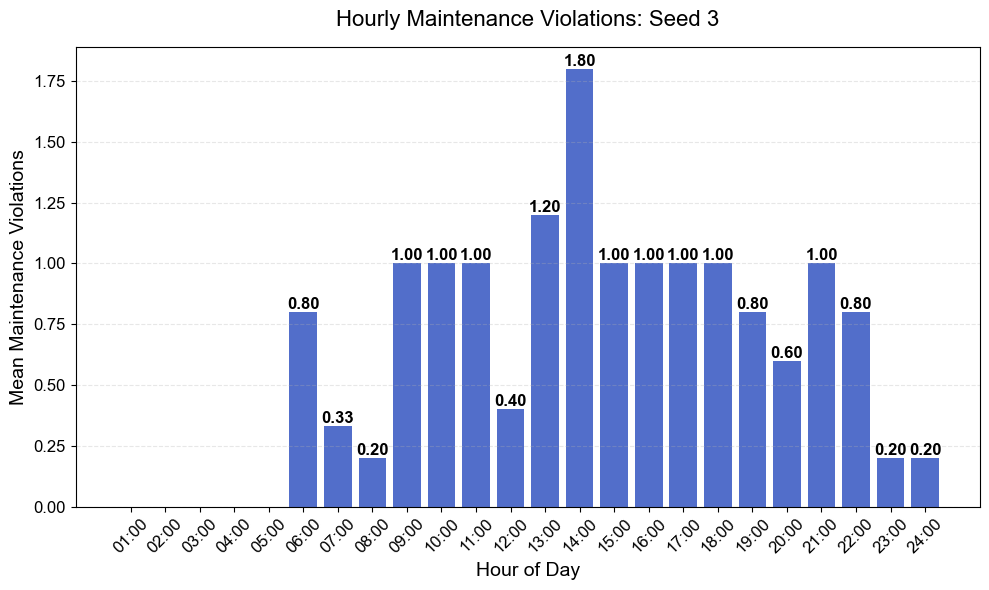

In [566]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_maintenance_violations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly maintenance violations.
    """
    # 1. Sum maintenance violations for each (Day, Hour) pair
    maintV_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Maintenance Violations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean violations per hour across days
    mean_hourly_maintV = (
        maintV_by_day_hour.groupby("Hour")["Maintenance Violations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_maintV["Hour"].tolist()
    maintV_vals = mean_hourly_maintV["Maintenance Violations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, maintV_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Maintenance Violations", fontsize=14)
    plt.title(f"Hourly Maintenance Violations: {title_label}", fontsize=16, pad=15)

    # Value labels OUTSIDE bars
    # We find max value to determine if we need extra headroom, though standard layout usually works
    for h, v in zip(hour_labels, maintV_vals):
        if v > 0.0:
            plt.text(
                h, 
                v,                # Y-position: Top of the bar
                f"{v:.2f}",       # Keep 2 decimals for small violation counts
                ha='center', 
                va='bottom',      # Align bottom of text to value
                color='black', 
                fontsize=12,
                fontweight='bold'
            )

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3) # Horizontal grid only usually looks cleaner

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"mean_maintenance_violations_{safe_label}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# Define styling
bar_color = colors[5][1]   # Blue (as requested)

if selection_mode == "all":
    print(f"Generating maintenance violation plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_hourly_maintenance_violations(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}",
            color_hex=bar_color
        )

else:
    # Single or Average Mode
    print(f"Generating maintenance violation plot for: {source_label}")
    
    plot_hourly_maintenance_violations(
        df_hourly=hourly_data,
        title_label=source_label,
        color_hex=bar_color
    )

## 4.4 Maintenance starvations

### 4.4.1 Accumulated for different parts of day

In [567]:

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# Define time blocks
# Note: Ranges in Python lists include the listed numbers.
time_blocks = {
    "Morning (07-10)": [7, 8, 9, 10],
    "Early Mid (11-12)": [11, 12],
    "Late Mid (13-14)": [13, 14],
    "Afternoon (15-18)": [15, 16, 17, 18],
    "Evening (19-22)": [19, 20, 21, 22]
}

# ---------------------------
# 2. ANALYSIS FUNCTION
# ---------------------------
def analyze_time_blocks(df_hourly):
    """
    Aggregates 'Maintenance Starvations' by specific time blocks.
    Returns a dictionary of results.
    """
    # Sum starvations by hour (across all days in the week)
    # If df_hourly is an average df, this gives Average Weekly Starvations per hour
    maint_by_hour = (
        df_hourly
        .groupby("Hour")["Maintenance Starvations"]
        .sum()
    )
    
    results = {}
    
    # Calculate sum for each block
    for block_name, hours in time_blocks.items():
        # intersection() ensures we don't crash if an hour is missing from data
        valid_hours = list(set(hours).intersection(maint_by_hour.index))
        val = maint_by_hour.loc[valid_hours].sum()
        results[block_name] = round(val, 2)
        
    # Calculate Ratio
    morning_val = results["Morning (07-10)"]
    afternoon_val = results["Afternoon (15-18)"]
    
    if afternoon_val > 0:
        ratio = round(morning_val / afternoon_val, 2)
    else:
        ratio = np.nan
        
    results["Ratio (Morn/Aft)"] = ratio
    return results

# ---------------------------
# 3. EXECUTION LOGIC
# ---------------------------

print(f"\n{'='*20} TIME OF DAY ANALYSIS {'='*20}")

if selection_mode == "all":
    # --- ALL SEEDS COMPARISON TABLE ---
    comparison_list = []
    
    print(f"Analyzing time blocks for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        stats = analyze_time_blocks(data_dict["hourly"])
        stats["Seed"] = seed_num
        comparison_list.append(stats)
    
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder cols to put Seed first
    cols = ["Seed"] + list(time_blocks.keys()) + ["Ratio (Morn/Aft)"]
    results_df = results_df[cols]
    
    print("\n")
    print(results_df.to_string(index=False))
    
    # Optional: Print Mean Ratio
    valid_ratios = results_df["Ratio (Morn/Aft)"].dropna()
    if not valid_ratios.empty:
        print(f"\nAverage Ratio across seeds: {valid_ratios.mean():.2f}")

else:
    # --- SINGLE OR AVERAGE MODE ---
    stats = analyze_time_blocks(hourly_data)
    
    print(f"\nMode: {source_label}")
    print("-" * 30)
    
    for block, val in stats.items():
        if block == "Ratio (Morn/Aft)":
            print("-" * 30)
            print(f"{block:<20} : {val}")
        else:
            print(f"{block:<20} : {val}")
            
    print("=" * 50)


==================== TIME OF DAY ANALYSIS ====================
Analyzing time blocks for 2 seeds...


 Seed  Morning (07-10)  Early Mid (11-12)  Late Mid (13-14)  Afternoon (15-18)  Evening (19-22)  Ratio (Morn/Aft)
    1              118                 39                47                145               42              0.81
    3              140                 68                89                154               44              0.91

Average Ratio across seeds: 0.86


### 4.4.2 Plot for mean over all hours of simulation horizon

Generating maintenance starvation plots for 2 seeds...


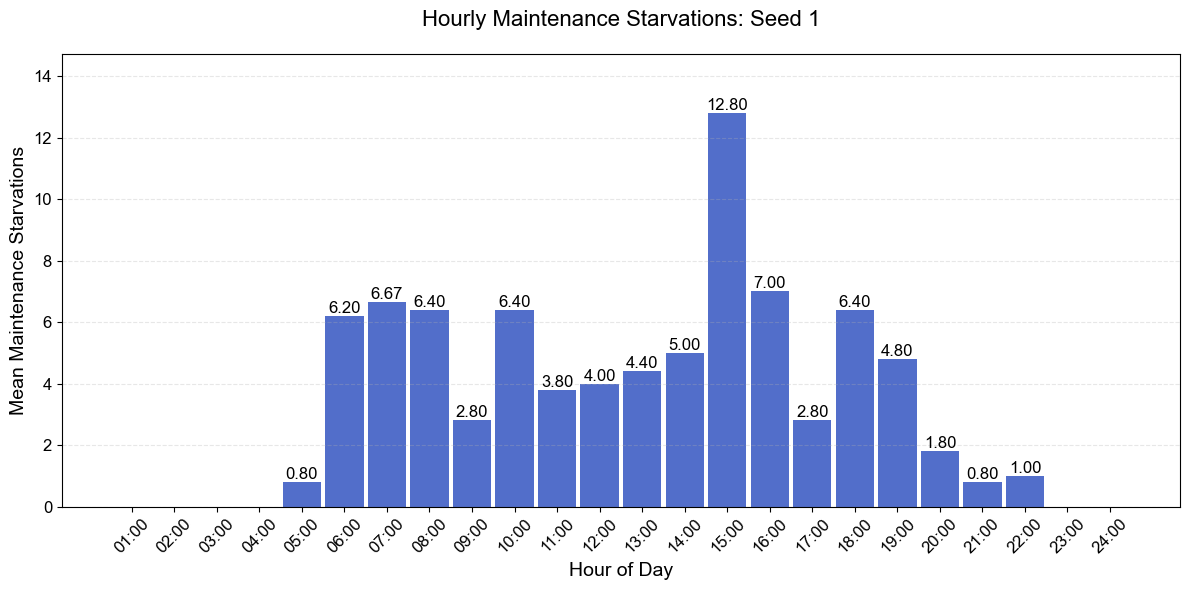

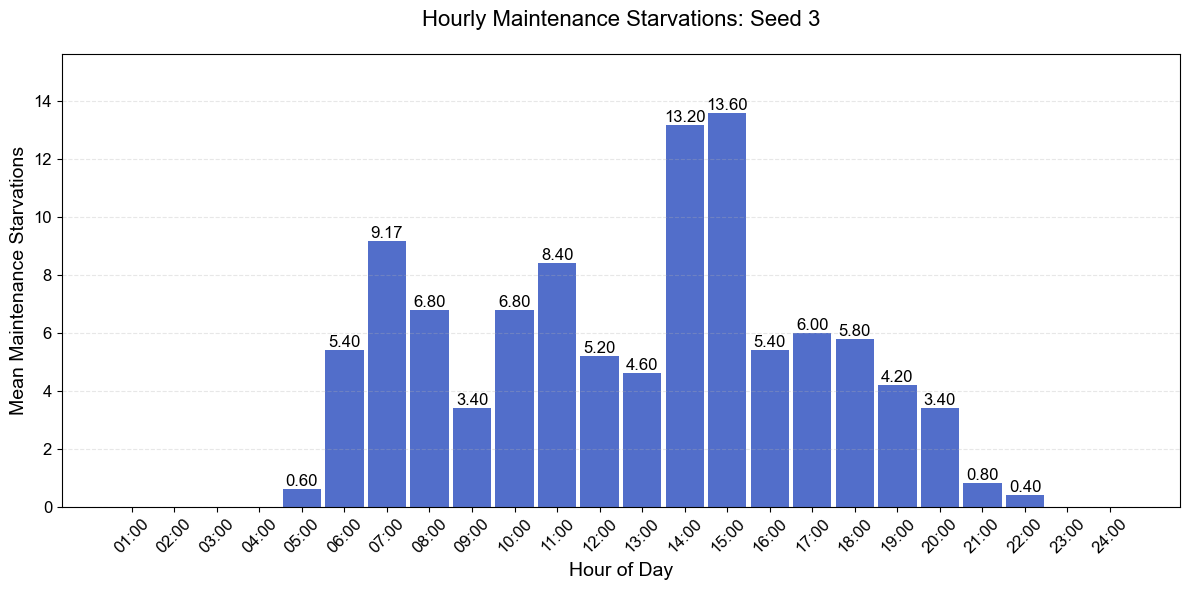

In [568]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_maintenance_starvations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly maintenance starvations.
    """
    # 1. Sum maintenance starvations for each (Day, Hour) pair
    # If df_hourly is averaged, this is the average sum per day
    maint_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Maintenance Starvations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean starvations per hour across days
    mean_hourly_maint = (
        maint_by_day_hour.groupby("Hour")["Maintenance Starvations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_maint["Hour"].tolist()
    maint_vals = mean_hourly_maint["Maintenance Starvations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    plt.bar(hour_labels, maint_vals, color=color_hex, alpha=1.0, width=0.9)

    # Labels and title
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Maintenance Starvations", fontsize=14)
    plt.title(f"Hourly Maintenance Starvations: {title_label}", fontsize=16, pad=20)

    # Value labels OUTSIDE bars
    for h, v in zip(hour_labels, maint_vals):
        if v > 0.0: # Check if value is significant
            plt.text(
                h, 
                v,                # Y-position: Top of the bar
                f"{v:.2f}", 
                ha='center', 
                va='bottom',      # Align bottom of text to the value point
                color='black',    
                fontsize=12
            )

    # Adjust Y-axis limit to make room for labels on top
    if maint_vals:
        max_val = max(maint_vals)
        if max_val > 0:
            plt.ylim(0, max_val * 1.15) 

    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"mean_maintenance_starvations_{safe_label}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# Define styling
bar_color = colors[5][1]  # Blue

if selection_mode == "all":
    print(f"Generating maintenance starvation plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_hourly_maintenance_starvations(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}",
            color_hex=bar_color
        )

else:
    # Single or Average Mode
    print(f"Generating maintenance starvation plot for: {source_label}")
    
    plot_hourly_maintenance_starvations(
        df_hourly=hourly_data,
        title_label=source_label,
        color_hex=bar_color
    )

## 4.5 Stacked barchart of long congestions and bike starvations

Generating stacked event plots for 2 seeds...


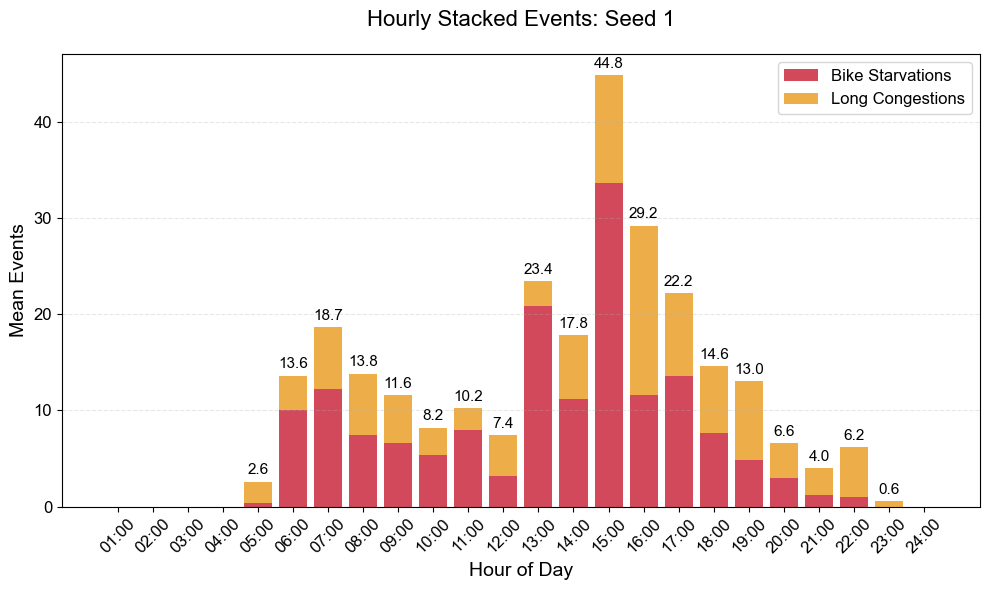

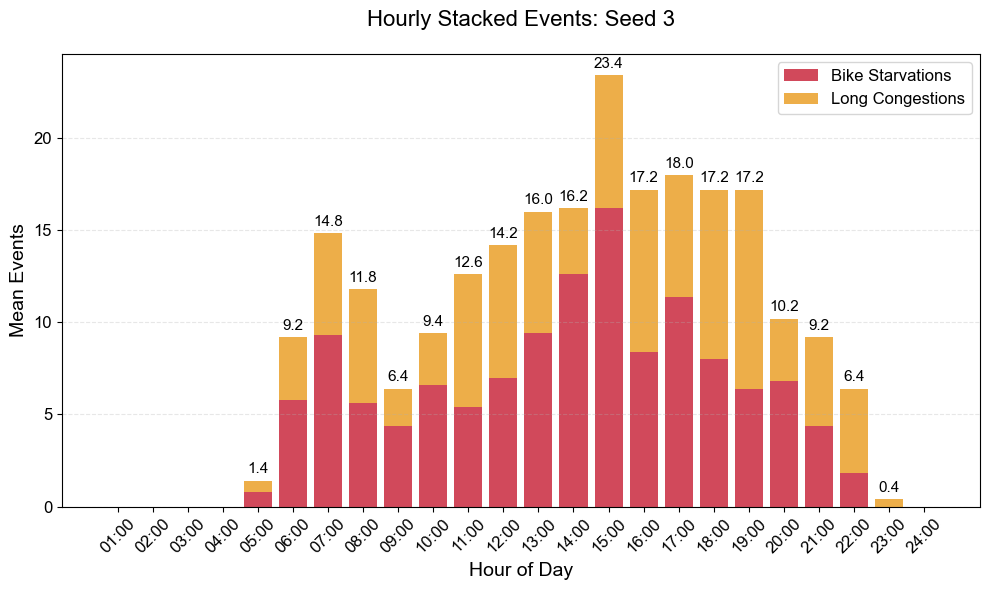

In [569]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_stacked_events(df_hourly, title_label):
    """
    Plots a stacked bar chart of Mean Bike Starvations (bottom) 
    and Mean Long Congestions (top) by hour.
    """
    # ---------------------------
    # 1. Data Processing
    # ---------------------------

    # Sum both metrics for each (Day, Hour) pair
    # (If df_hourly is averaged, this is the average sum per day)
    hourly_sums = (
        df_hourly.groupby(["Day", "Hour"])[["Bike Starvations", "Long Congestions"]]
        .sum()
        .reset_index()
    )

    # Compute mean per hour across all days
    mean_hourly = (
        hourly_sums.groupby("Hour")[["Bike Starvations", "Long Congestions"]]
        .mean()
        .reset_index()
    )

    # Extract lists
    hours = mean_hourly["Hour"].tolist()
    starv_vals = mean_hourly["Bike Starvations"].tolist()
    cong_vals = mean_hourly["Long Congestions"].tolist()

    # Calculate total height for labeling and axis limits
    total_vals = [s + c for s, c in zip(starv_vals, cong_vals)]

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # ---------------------------
    # 2. Plotting
    # ---------------------------

    plt.figure(figsize=(10, 6))

    # Define colors
    color_cong = colors[4][1]   # Sage Green (Top)
    color_starv = colors[3][1]  # Muted Orange (Bottom)

    # Plot Bottom Bar (Starvations)
    p1 = plt.bar(hour_labels, starv_vals, color=color_starv, label="Bike Starvations", alpha=1.0, width=0.8)

    # Plot Top Bar (Congestions) - use 'bottom' parameter to stack on starvations
    p2 = plt.bar(hour_labels, cong_vals, bottom=starv_vals, color=color_cong, label="Long Congestions", alpha=1.0, width=0.8)

    # ---------------------------
    # 3. Formatting
    # ---------------------------

    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Events", fontsize=14)
    plt.title(f"Hourly Stacked Events: {title_label}", fontsize=16, pad=20)
    plt.legend(fontsize=12, loc='upper right')

    # Calculate threshold for label spacing
    max_height = max(total_vals) if total_vals else 0
    threshold = 0.01 * max_height if max_height > 0 else 0.1

    # Label the TOTAL height on top of the stack
    for h, total in zip(hour_labels, total_vals):
        if total > 0.05: # Only label significant totals
            plt.text(h, total + threshold,
                     f"{total:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=11)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"stacked_starvations_congestions_{safe_label}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

if selection_mode == "all":
    print(f"Generating stacked event plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_hourly_stacked_events(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}"
        )

else:
    # Single or Average Mode
    print(f"Generating stacked event plot for: {source_label}")
    
    plot_hourly_stacked_events(
        df_hourly=hourly_data,
        title_label=source_label
    )

# 5 Vehicle insight

In [570]:
# ---------------------------
# 1. METRIC FUNCTION
# ---------------------------
def print_vehicle_summary(df_vehicle, title_label, scale_factor=1):
    """
    Calculates and prints summary metrics for vehicle visits.
    
    Args:
        df_vehicle: DataFrame containing vehicle log.
        title_label: String label (e.g., "Seed 1" or "Average").
        scale_factor: int. Used to normalize total counts if df_vehicle contains 
                      stacked data from multiple seeds.
    """
    # 1. Total Visits (Normalized)
    raw_visits = df_vehicle.shape[0]
    avg_visits = raw_visits / scale_factor
    
    # 2. Unique Stations Visited
    # This metric is tricky for averages. 
    # usually, we just want to know "How many unique stations were visited in this dataset?"
    # For a single seed, it's exact. For stacked data, it shows the union of all stations visited across all runs.
    unique_stations = df_vehicle["Station ID"].nunique()
    
    print(f"--- {title_label} ---")
    print(f"Total Visits (avg/run):  {avg_visits:.1f}")
    print(f"Unique Stations Visited: {unique_stations}")
    print("") # Spacer

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

print(f"\n{'='*20} VEHICLE VISIT SUMMARY {'='*20}")

if selection_mode == "all":
    print(f"Summarizing vehicle logs for {len(all_seeds_data)} seeds...\n")
    
    for seed_num, data_dict in all_seeds_data.items():
        print_vehicle_summary(
            df_vehicle=data_dict["vehicle"],
            title_label=f"Seed {seed_num}",
            scale_factor=1
        )

else:
    # Determine Scale Factor
    # If "average", vehicle_df is stacked (N seeds), so we divide by N to get "Avg Visits per Week".
    # If int (single), divide by 1.
    scale = len(available_seeds) if selection_mode == "average" else 1
    
    print_vehicle_summary(
        df_vehicle=vehicle_df,
        title_label=source_label,
        scale_factor=scale
    )

print("="*50)


==================== VEHICLE VISIT SUMMARY ====================
Summarizing vehicle logs for 2 seeds...

--- Seed 1 ---
Total Visits (avg/run):  406.0
Unique Stations Visited: 48

--- Seed 3 ---
Total Visits (avg/run):  405.0
Unique Stations Visited: 55



In [571]:
# Extract numeric id: "S35" → 35
vehicle_df["id"] = vehicle_df["Station ID"].str.extract(r"S(\d+)").astype(int)

# Count visits per station id
station_counts = (
    vehicle_df
        .groupby("id")
        .size()
        .reset_index(name="num_visits")
)

# Join on integer id
stations_with_visits = stations_df.merge(station_counts, on="id", how="left")

# Fill stations that never appear in visits
stations_with_visits["num_visits"] = stations_with_visits["num_visits"].fillna(0).astype(int)

stations_with_visits.head(70)


,id,location,is_depot,capacity,num_bikes,leave_intensities,leave_intensities_stdev,arrive_intensities,arrive_intensities_stdev,move_probabilities,lat,lon,num_visits
0,0,"[63.40772802863199, 10.39705323440262]",False,21,10,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.2, 0.8, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.400000000000...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8000000...","[[[0.014925373134328358, 0.014925373134328358,...",63.407728,10.397053,5
1,1,"[63.414746566093925, 10.397386363673064]",False,15,7,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.2, 0.4, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.6, 0.0, 0.2,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[[0.014925373134328358, 0.014925373134328358,...",63.414747,10.397386,3
2,2,"[63.436025749373755, 10.430998463879718]",False,24,12,"[[0.0, 0.0, 0.0, 0.0, 0.2, 1.8, 0.4, 0.2, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 2.22...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.400000000000...","[[[0.014925373134328358, 0.014925373134328358,...",63.436026,10.430998,2
3,3,"[63.42126270770024, 10.386516005020496]",False,18,8,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.4, 0.0, 0.4,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.7999999999999999,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 1.4, 1.6, 0.2, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 1.95...","[[[0.014925373134328358, 0.014925373134328358,...",63.421263,10.386516,6
4,4,"[63.43337733865644, 10.401074857528158]",False,18,8,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 1.0, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.4000000000000001,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 2.2, 0.8, 1.2, 0.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 2.31...","[[[0.014925373134328358, 0.014925373134328358,...",63.433377,10.401075,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,62,"[63.427896581278105, 10.403341750766884]",False,26,13,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 2.8, 1.8, 1.2,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.8330302779823362,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 1.0, 1.2, 1.4, 1.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 1.54...","[[[0.014925373134328358, 0.014925373134328358,...",63.427897,10.403342,11
63,63,"[63.42994558007871, 10.391905842869932]",False,28,14,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.2, 2.0, 1.0, 1.8,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.1661903789690602,...","[[0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 3.0, 1.6, 3.2,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 0.74...","[[[0.014925373134328358, 0.014925373134328358,...",63.429946,10.391906,14
64,64,"[63.43527713641004, 10.405813604593277]",False,13,6,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.8, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.400000000000...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.4, 1.0, 0.0, 0.6,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.4966629547095764,...","[[[0.014925373134328358, 0.014925373134328358,...",63.435277,10.405814,11
65,65,"[63.43660495943216, 10.425844341516495]",False,25,13,"[[0.0, 0.0, 0.0, 0.0, 1.6, 5.4, 1.2, 1.0, 0.4,...","[[0.0, 0.0, 0.0, 0.0, 1.854723699099141, 2.576...","[[0.0, 0.0, 0.0, 0.0, 0.2, 0.4, 0.0, 0.4, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.4000000000000001, 0.48...","[[[0.014925373134328358, 0.014925373134328358,...",63.436605,10.425844,4


## 5.1 Unique stations visited per hour

Generating visit heatmaps for 2 seeds...


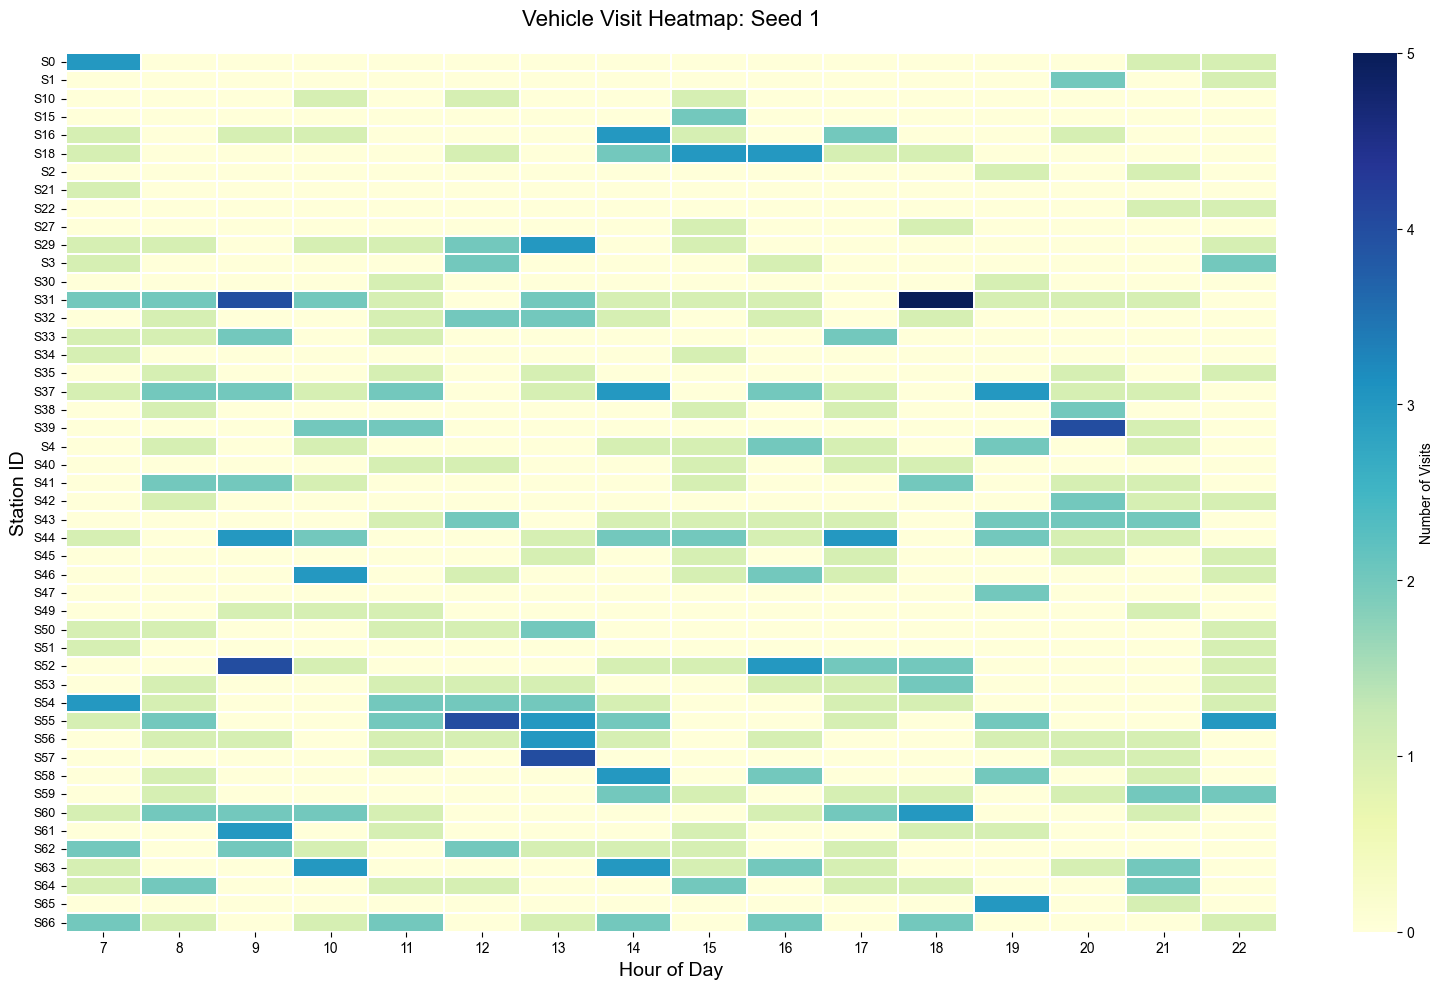

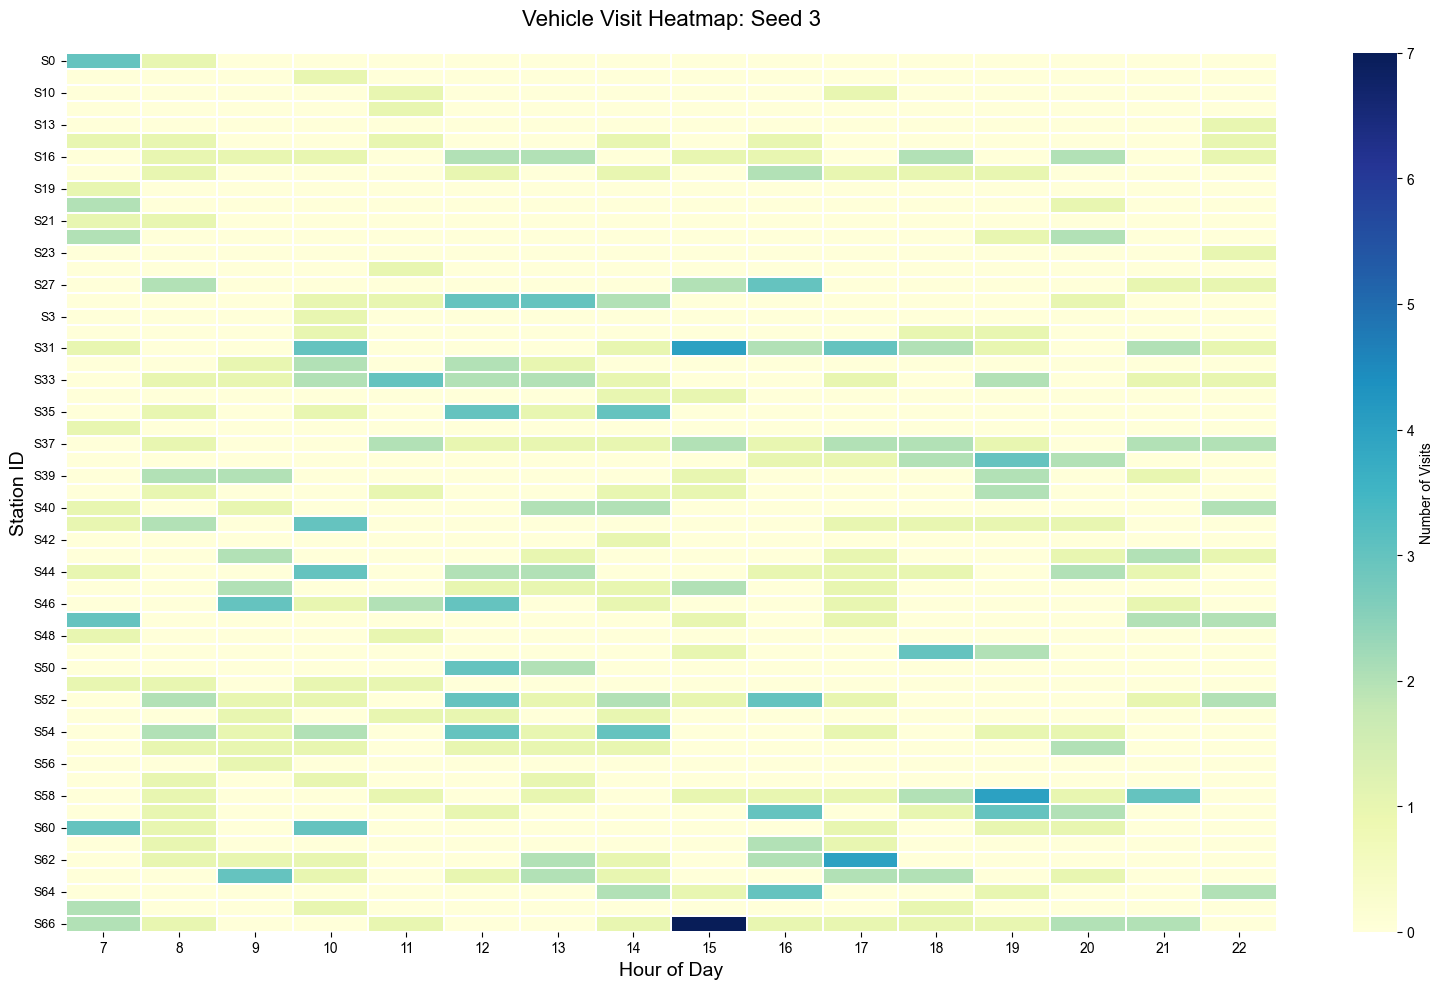

In [572]:

# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_visit_heatmap(df_vehicle, title_label, scale_factor=1):
    """
    Plots a heatmap of vehicle visits (Station ID vs Hour).
    
    Args:
        df_vehicle: DataFrame containing vehicle log.
        title_label: String label for the chart.
        scale_factor: int. Used to normalize visit counts if df_vehicle contains 
                      stacked data from multiple seeds.
    """
    # 1. Count visits per station per hour
    visits_matrix = (
        df_vehicle.groupby(["Station ID", "Hour"])
        .size()
        .reset_index(name="visits")
    )
    
    # Normalize counts if using stacked data (Average Mode)
    if scale_factor > 1:
        visits_matrix["visits"] = visits_matrix["visits"] / scale_factor

    # 2. Pivot to station x hour matrix
    heatmap_data = visits_matrix.pivot(index="Station ID", columns="Hour", values="visits")

    # Replace NaN with 0
    heatmap_data = heatmap_data.fillna(0)
    
    # Sort Index (Stations) for cleaner view
    heatmap_data = heatmap_data.sort_index()

    # 3. Plotting
    plt.figure(figsize=(16, 10))
    
    ax = sns.heatmap(
        heatmap_data,
        cmap="YlGnBu",
        linewidths=0.01,
        cbar_kws={"label": "Avg Number of Visits" if scale_factor > 1 else "Number of Visits"}
    )

    plt.title(f"Vehicle Visit Heatmap: {title_label}", fontsize=16, pad=20)
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Station ID", fontsize=14)

    plt.xticks(rotation=0) # Keep hour labels horizontal
    plt.yticks(rotation=0, fontsize=9) # Keep station labels horizontal if space permits
    
    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"vehicle_visit_heatmap_{safe_label}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

if selection_mode == "all":
    print(f"Generating visit heatmaps for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_visit_heatmap(
            df_vehicle=data_dict["vehicle"],
            title_label=f"Seed {seed_num}",
            scale_factor=1
        )

else:
    # Determine Scale Factor for Average Mode
    scale = len(available_seeds) if selection_mode == "average" else 1
    
    print(f"Generating visit heatmap for: {source_label}")
    
    plot_visit_heatmap(
        df_vehicle=vehicle_df,
        title_label=source_label,
        scale_factor=scale
    )

## 5.2 Plot over visit frequency on map

In [573]:
def visit_color(n):
    if n == 0:
        return "light green"
    elif 1 <= n <= 5:
        return "#f7f148"
    elif 6 <= n <= 15:
        return "#f3903f"
    elif 16 <= n <= 25:
        return "#ed683c"
    else:
        return "#ce0011"




# Center map on mean lat/lon of all stations
center_lat = stations_with_visits["lat"].mean()
center_lon = stations_with_visits["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# (optional) show all stations, or only top N
#top_stations = stations_with_visits.sort_values("num_visits", ascending=False).head(50)
top_stations = stations_with_visits  # <- all
print(top_stations["num_visits"].head(70))

max_visits = top_stations["num_visits"].max()
min_radius = 5
max_radius = 20 if max_visits > 0 else 6

for _, row in top_stations.iterrows():
    n = row["num_visits"]
    # scale radius with visits, but keep within a nice range
    radius = min_radius if max_visits == 0 else (
        min_radius + (n / max_visits) * (max_radius - min_radius)
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        fill=True,
        color=visit_color(n),
        fill_color=visit_color(n),
        fill_opacity=0.8,
        popup=f"Station S{row['id']}<br>Visits: {n}",
    ).add_to(m)

m.save(f"trondheim_map_S{seed}_A{alpha_value}.html")

0      5
1      3
2      2
3      6
4     10
      ..
62    11
63    14
64    11
65     4
66    14
Name: num_visits, Length: 67, dtype: int64


## 5.3 Vehicle maintenance allocation

Generating maintenance timelines for 2 seeds...


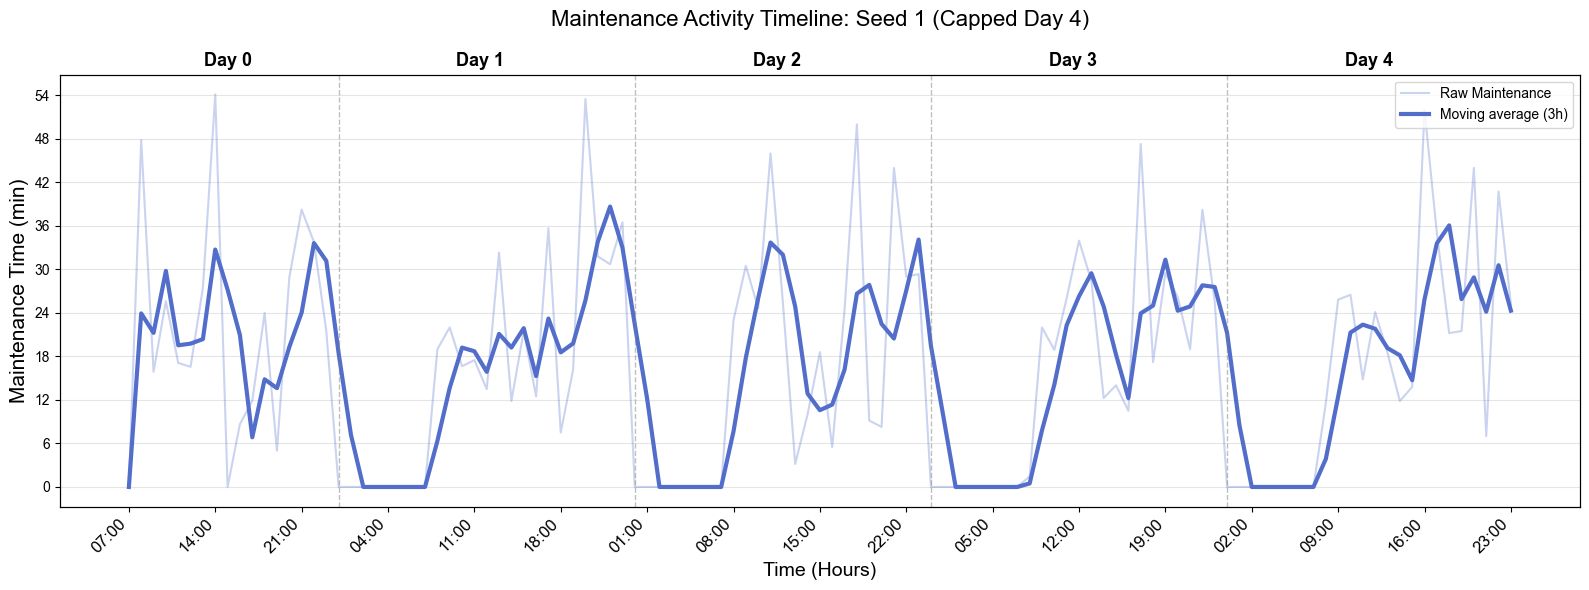

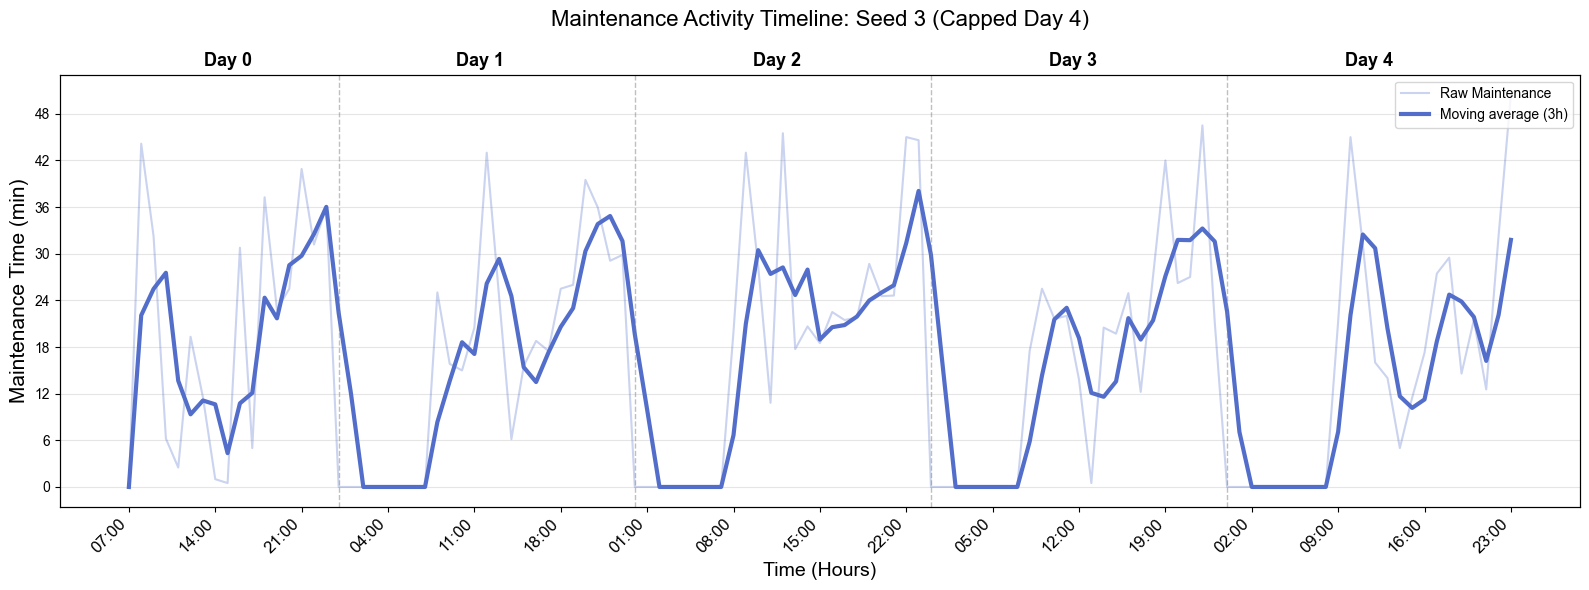

In [578]:
def plot_maintenance_timeline(df_hourly, title_label):
    """
    Plots the timeline of Maintenance Time (Raw vs Moving Average).
    Includes logic to cap at Day 4 + 1 Hour for a clean visual finish.
    """
    # 1. PREPARE DATA & APPLY CAP
    g = apply_time_cap(df_hourly)
    
    if g.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return
    
    # Ensure sorting by time
    if "Time (minutes)" in g.columns:
        g = g.sort_values("Time (minutes)")
    else:
        g = g.sort_values(["Day", "Hour"])
        
    g = g.reset_index(drop=True)
    
    # Calculate Moving Average (Window = 3 hours)
    g["Maintenance_MA"] = g["Maintenance Time (minutes)"].rolling(window=3, min_periods=1).mean()
    
    # Create Label for bottom axis
    g["hour_label"] = g["Hour"].astype(int).astype(str).str.zfill(2) + ":00"

    # 2. IDENTIFY DAY BOUNDARIES
    # Find indices where the day changes (Day i != Day i-1)
    day_change_idx = g.index[g["Day"].ne(g["Day"].shift())].tolist()
    
    # Skip the very first index (0) if it's the start of the sim
    boundary_positions = day_change_idx[1:]

    # 3. CALCULATE DAY CENTERS (For Top Axis)
    day_centers = []
    day_labels = []
    for day_val in g["Day"].unique():
        # Skip Day 5 label if it's just the single cutoff point
        if CAP_AT_DAY_4 and day_val >= 5:
            continue
            
        idxs = g.index[g["Day"] == day_val]
        if len(idxs) > 0:
            center = (idxs[0] + idxs[-1]) / 2
            day_centers.append(center)
            day_labels.append(f"Day {int(day_val)}")

    # 4. PLOTTING
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Use the reference color (Olive Green)
    line_color = colors[5][1]
    x = g.index 

    # Plot Raw values (Low Alpha)
    ax.plot(x, g["Maintenance Time (minutes)"], alpha=0.3, 
            label="Raw Maintenance", color=line_color)

    # Plot Moving average (Thick line)
    ax.plot(x, g["Maintenance_MA"], linewidth=3, color=line_color, 
            label="Moving average (3h)")

    # Vertical lines (Day boundaries)
    for pos in boundary_positions:
        ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    # --- Y-AXIS GRID & FORMATTING ---
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) 
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.2, color='gray')
    ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
    
    ax.set_ylabel("Maintenance Time (min)", fontsize=15)
    ax.set_xlabel("Time (Hours)", fontsize=14)
    
    # Dynamic Title
    cap_text = "(Capped Day 4)" if CAP_AT_DAY_4 else "(Full Week)"
    ax.set_title(f"Maintenance Activity Timeline: {title_label} {cap_text}", fontsize=16, pad=35)

    # --- BOTTOM X-AXIS (Hours) ---
    # Calculate step to prevent label overlap.
    denom = 15 if CAP_AT_DAY_4 else 25
    step = max(1, len(g) // denom)
    
    ax.set_xticks(list(x)[::step])
    ax.set_xticklabels(g["hour_label"].iloc[::step], 
                       rotation=45, ha="right", fontsize=12)

    # --- TOP X-AXIS (Day Labels) ---
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim()) # Sync limits exactly
    ax2.set_xticks(day_centers)
    ax2.set_xticklabels(day_labels, fontsize=13, fontweight='bold')
    
    ax2.xaxis.set_ticks_position("top")
    ax2.xaxis.set_label_position("top")
    ax2.tick_params(axis='x', length=0) # Hide tick marks

    ax.legend(loc="upper right", frameon=True)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"maintenance_time_{safe_label}_capped_{CAP_AT_DAY_4}.svg")
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

if selection_mode == "all":
    print(f"Generating maintenance timelines for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_maintenance_timeline(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}"
        )

else:
    # Single or Average Mode
    print(f"Generating maintenance timeline for: {source_label}")
    
    plot_maintenance_timeline(
        df_hourly=hourly_data,
        title_label=source_label
    )

## 5.4 Total time spent on maintenance vs rebalancing
This graph shows 

Generating work profile plots for 2 seeds...


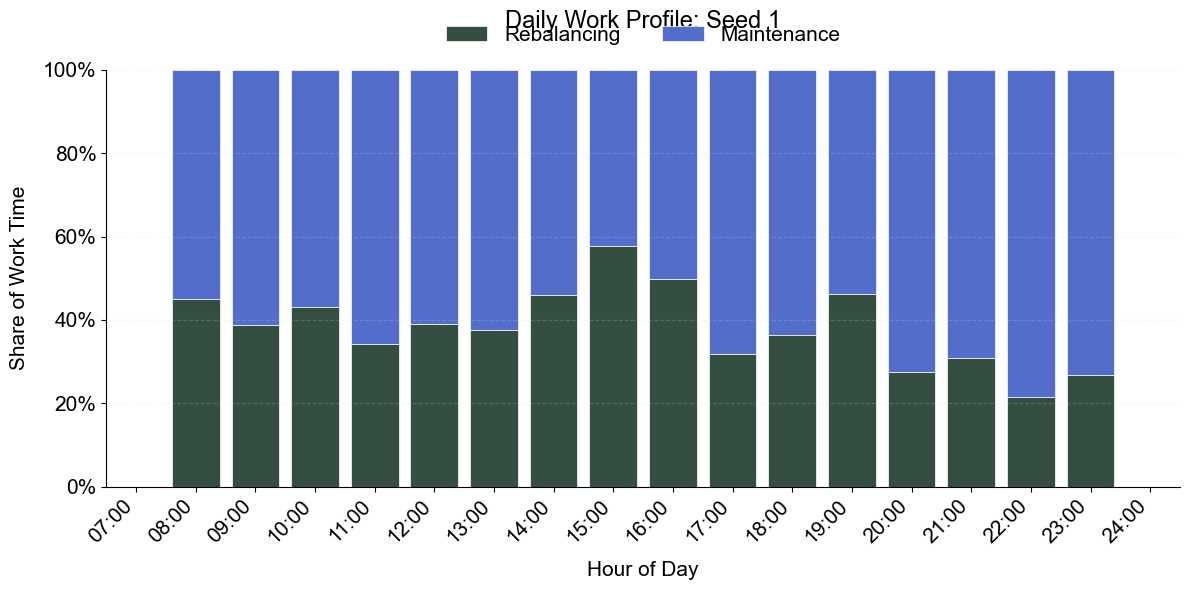

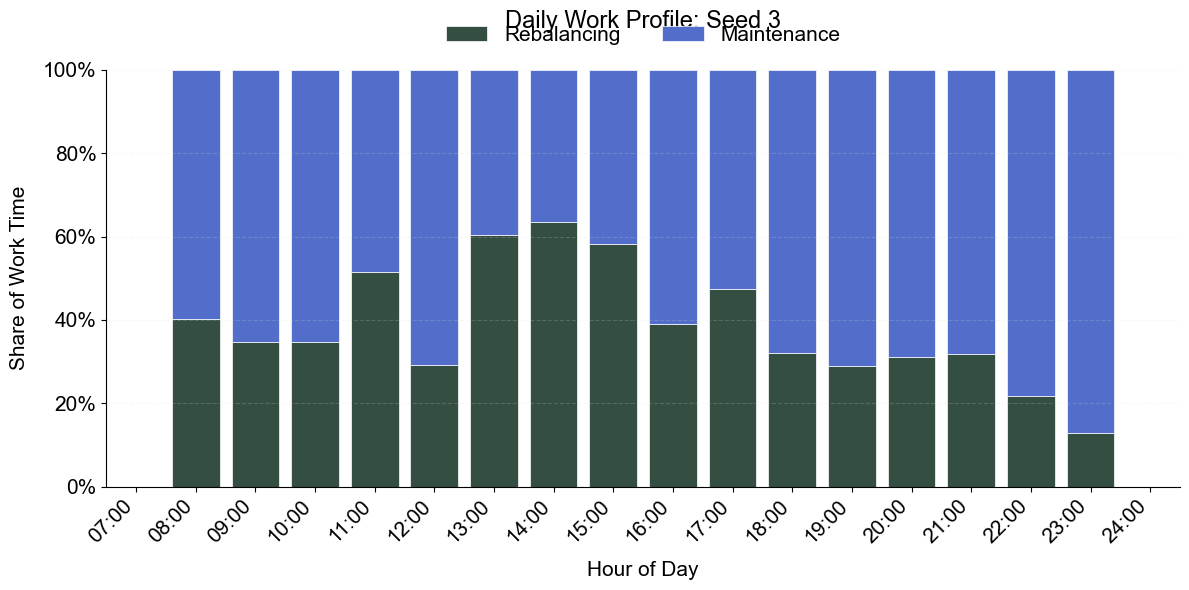

In [575]:


# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_work_time_profile(df_hourly, title_label):
    """
    Plots the daily profile of work share (Rebalancing vs Maintenance)
    as a stacked percentage bar chart.
    """
    # ==========================================
    # 1. DATA PREPARATION
    # ==========================================

    # Filter out hours before 7 AM (if desired)
    hourly_df_filtered = df_hourly[df_hourly['Hour'] >= 7].copy()

    # Calculate raw minutes per hour
    # Assumption: 0.5 minutes per bike move (Pickup/Delivery)
    hourly_df_filtered['Rebalancing Time'] = (hourly_df_filtered['Bike Pickups'] + hourly_df_filtered['Bike Deliveries']) * 0.5
    hourly_df_filtered['Maintenance Time'] = hourly_df_filtered['Maintenance Time (minutes)']

    # Group by 'Hour' to find the average (across all days in the simulation)
    daily_profile = hourly_df_filtered.groupby("Hour")[['Rebalancing Time', 'Maintenance Time']].mean()

    # Re-calculate fractions
    daily_profile['Total Activity'] = daily_profile['Rebalancing Time'] + daily_profile['Maintenance Time']
    
    # Avoid division by zero
    daily_profile['Fraction Rebalancing'] = daily_profile.apply(
        lambda row: row['Rebalancing Time'] / row['Total Activity'] if row['Total Activity'] > 0 else 0, axis=1
    )
    daily_profile['Fraction Maintenance'] = daily_profile.apply(
        lambda row: row['Maintenance Time'] / row['Total Activity'] if row['Total Activity'] > 0 else 0, axis=1
    )

    # Fill NaNs and Sort
    daily_profile = daily_profile.fillna(0).sort_index()

    # ==========================================
    # 2. PLOTTING
    # ==========================================
    
    # Set safe defaults if variables aren't in scope
    local_font_size = font_size if 'font_size' in globals() else 12

    # Set global font family
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    hours = daily_profile.index
    color_maint = colors[5][1]      # Blue Accent
    color_rebal = colors[2][1]      # Muted Orange/Terra cotta

    # --- PLOT ---
    ax.bar(hours, daily_profile['Fraction Rebalancing'],
           color=color_rebal, label='Rebalancing',
           width=0.8, edgecolor='white', linewidth=0.5)

    ax.bar(hours, daily_profile['Fraction Maintenance'],
           bottom=daily_profile['Fraction Rebalancing'],
           color=color_maint, label='Maintenance',
           width=0.8, edgecolor='white', linewidth=0.5)

    # --- AESTHETICS ---

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#000000")
    ax.spines['bottom'].set_color("#000000")

    # Grid
    ax.grid(True, which='major', axis='y', linestyle='--', color='#DDDDDD', zorder=0, alpha=0.2)
    ax.grid(False, axis='x')

    # X-Axis Ticks
    ax.set_xticks(hours)
    ax.set_xticklabels([f"{int(h):02d}:00" for h in hours], 
                       rotation=45, color="#000000", ha="right", fontsize=local_font_size)

    # Y-Axis Ticks
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.tick_params(axis='y', colors="#000000", labelsize=local_font_size)

    # Format Y-axis as percentage
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

    # Limits
    ax.set_ylim(0, 1.0)
    if not hours.empty:
        ax.set_xlim(hours.min()-0.5, hours.max()+0.5)

    # Labels
    ax.set_ylabel("Share of Work Time", fontsize=local_font_size, color="#000000", labelpad=10)
    ax.set_xlabel("Hour of Day", fontsize=local_font_size, color="#000000", labelpad=10)
    ax.set_title(f"Daily Work Profile: {title_label}", fontsize=local_font_size+2, pad=30)

    # Legend
    ax.legend(frameon=False, fontsize=local_font_size, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"daily_worktime_profile_{safe_label}.svg", bbox_inches='tight')
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

if selection_mode == "all":
    print(f"Generating work profile plots for {len(all_seeds_data)} seeds...")
    
    for seed_num, data_dict in all_seeds_data.items():
        plot_work_time_profile(
            df_hourly=data_dict["hourly"],
            title_label=f"Seed {seed_num}"
        )

else:
    # Single or Average Mode
    print(f"Generating work profile plot for: {source_label}")
    
    plot_work_time_profile(
        df_hourly=hourly_data,
        title_label=source_label
    )

# 6 - Vehicle insight

## 6.1 stastion to station flow

In [576]:

# ---------------------------
# 1. ANALYSIS FUNCTION
# ---------------------------
def analyze_vehicle_transitions(df_vehicle, title_label, scale_factor=1):
    """
    Analyzes vehicle movements to find the most common 'From -> To' station transitions.
    """
    df = df_vehicle.copy()

    # Sort by vehicle and time to ensure correct sequence
    # Note: 'Seed' column might not exist if loading a single CSV, 
    # but grouping by 'Vehicle ID' is usually safe per file.
    if "Seed" in df.columns:
        df = df.sort_values(["Seed", "Vehicle ID", "Time (minutes)"])
        group_cols = ["Seed", "Vehicle ID"]
    else:
        df = df.sort_values(["Vehicle ID", "Time (minutes)"])
        group_cols = ["Vehicle ID"]

    # For each vehicle, shift Station ID to get "next" station
    df["Next Station ID"] = df.groupby(group_cols)["Station ID"].shift(-1)

    # Drop last visits (no "next" station)
    transitions = df.dropna(subset=["Next Station ID"]).copy()

    # Count how often each directed pair occurs
    transition_counts = (
        transitions
        .groupby(["Station ID", "Next Station ID"])
        .size()
        .reset_index(name="Count")
        .rename(columns={"Station ID": "From", "Next Station ID": "To"})
    )
    
    # Normalize count if this is an aggregate of multiple seeds
    if scale_factor > 1:
        transition_counts["Avg Count/Run"] = transition_counts["Count"] / scale_factor
        sort_col = "Avg Count/Run"
    else:
        sort_col = "Count"

    # Keep only strongest flows (top 10 edges)
    top_flows = transition_counts.sort_values(sort_col, ascending=False).head(10)
    
    # Formatting for display
    print(f"\n--- Top 10 Vehicle Transitions: {title_label} ---")
    if scale_factor > 1:
        print(top_flows[["From", "To", "Avg Count/Run"]].to_string(index=False))
    else:
        print(top_flows[["From", "To", "Count"]].to_string(index=False))

    return top_flows

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

print(f"\n{'='*20} VEHICLE ROUTE ANALYSIS {'='*20}")

if selection_mode == "all":
    # Calculate for each seed
    for seed_num, data_dict in all_seeds_data.items():
        analyze_vehicle_transitions(
            df_vehicle=data_dict["vehicle"],
            title_label=f"Seed {seed_num}",
            scale_factor=1
        )

else:
    # Single or Average Mode
    scale = len(available_seeds) if selection_mode == "average" else 1
    
    analyze_vehicle_transitions(
        df_vehicle=vehicle_df,
        title_label=source_label,
        scale_factor=scale
    )
    
print("="*50)


==================== VEHICLE ROUTE ANALYSIS ====================

--- Top 10 Vehicle Transitions: Seed 1 ---
From  To  Count
 S66 S31      8
 S37 S37      6
 S39 S39      6
 S60 S41      5
 S31 S66      5
 S52 S44      5
 S43 S43      5
 S44 S16      5
 S55 S55      4
 S56 S55      4

--- Top 10 Vehicle Transitions: Seed 3 ---
From  To  Count
 S66 S31      6
 S58 S58      6
 S31 S66      6
 S55 S54      5
 S66 S66      5
 S58 S37      5
 S52 S33      4
 S52 S44      4
 S60 S66      4
 S47 S47      4


## 6.2 Vehicle decision logic


In [577]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CHRONOLOGICAL COMPARISON FUNCTION
# ---------------------------
def compare_decisions_chronologically(seeds_data_dict):
    """
    Aligns vehicle movements by sequence step (Move 1, Move 2...) 
    and prints them side-by-side to find where they diverge.
    """
    print(f"Aligning chronological sequences for {len(seeds_data_dict)} seeds...")
    
    # List to hold the sequence for each seed
    all_sequences = []

    # 1. Extract Sequence for every seed
    for seed, data in seeds_data_dict.items():
        df = data["vehicle"].copy()
        
        # Sort to ensure chronological order
        # We group by Vehicle ID to handle multiple vehicles correctly
        if "Vehicle ID" in df.columns:
            df = df.sort_values(["Vehicle ID", "Time (minutes)"])
            # Create a "Step" counter (1, 2, 3...) for each vehicle
            df["Step"] = df.groupby("Vehicle ID").cumcount() + 1
            df["Vehicle_Step"] = df["Vehicle ID"].astype(str) + "_Step_" + df["Step"].astype(str).str.zfill(3)
        else:
            # Fallback for single vehicle without ID
            df = df.sort_values("Time (minutes)")
            df["Step"] = range(1, len(df) + 1)
            df["Vehicle_Step"] = "V0_Step_" + df["Step"].astype(str).str.zfill(3)
            
        # Select just the columns we need
        # We store the Station ID as the value
        seq_df = df[["Vehicle_Step", "Station ID"]].rename(columns={"Station ID": f"Seed {seed}"})
        seq_df = seq_df.set_index("Vehicle_Step")
        
        all_sequences.append(seq_df)

    # 2. Merge into one Master Timeline
    # Outer join aligns them by Step Number
    timeline = pd.concat(all_sequences, axis=1)
    
    # Sort index to ensure Step 1 comes before Step 2
    timeline = timeline.sort_index()

    # 3. Analyze Divergence
    # Check if all columns (Seeds) in a row have the same value
    # We use .eq(..., axis=0) to compare all against the first column
    first_col = timeline.columns[0]
    
    # Logic: Are all seed columns equal to the first seed column?
    # (We fillna with a placeholder because NaN != NaN in pandas usually)
    is_match = timeline.fillna("MISSING").eq(timeline[first_col].fillna("MISSING"), axis=0).all(axis=1)
    
    timeline["Status"] = np.where(is_match, "Match", "[!] DIVERGENCE")

    # 4. PRINTING (Custom Formatter)
    print("\n" + "="*100)
    print(f"CHRONOLOGICAL DECISION TIMELINE")
    print(f"Tracking sequence of stations visited. (Sorted by Vehicle -> Step)")
    print("="*100)
    
    # Adjust display options to show the whole table width
    pd.set_option('display.max_rows', 500)  # Show up to 500 moves
    pd.set_option('display.max_columns', 50)
    pd.set_option('display.width', 1000)
    
    # Show the first 100 steps, or specific slice
    # You can change .head(100) to .iloc[0:100] etc.
    display_df = timeline.fillna("-")
    
    print(display_df)
    
    print("="*100)
    
    # Summary of Stability
    total_steps = len(timeline)
    divergent_steps = len(timeline[timeline["Status"] == "[!] DIVERGENCE"])
    
    print(f"Total Steps Compared: {total_steps}")
    print(f"Divergent Steps:      {divergent_steps}")
    if total_steps > 0:
        match_pct = (1 - divergent_steps/total_steps) * 100
        print(f"Sequence Similarity:  {match_pct:.1f}%")

        # Find FIRST divergence
        divergence_idx = timeline.index[timeline["Status"] == "[!] DIVERGENCE"]
        if not divergence_idx.empty:
            print(f"First Divergence occurs at: {divergence_idx[0]}")
    
    # Reset options
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')

    return timeline

# ---------------------------
# 2. EXECUTION
# ---------------------------

if selection_mode == "all":
    chronological_table = compare_decisions_chronologically(all_seeds_data)

elif selection_mode == "average":
    # Fallback: reload seeds
    try:
        print("Re-loading individual seeds for comparison...")
        temp_seeds = {s: load_single_seed(s) for s in available_seeds}
        chronological_table = compare_decisions_chronologically(temp_seeds)
    except Exception as e:
        print(f"Error: {e}")

else:
    print("Chronological comparison requires multiple seeds (Mode 'all' or 'average').")

Aligning chronological sequences for 2 seeds...

CHRONOLOGICAL DECISION TIMELINE
Tracking sequence of stations visited. (Sorted by Vehicle -> Step)
             Seed 1 Seed 3          Status
Vehicle_Step                              
V0_Step_001      S0     S0           Match
V0_Step_002     S21    S21           Match
V0_Step_003      S0     S0           Match
V0_Step_004      S0     S0           Match
V0_Step_005     S35    S21  [!] DIVERGENCE
V0_Step_006     S50     S0  [!] DIVERGENCE
V0_Step_007     S54    S35  [!] DIVERGENCE
V0_Step_008     S53    S57  [!] DIVERGENCE
V0_Step_009     S33    S54  [!] DIVERGENCE
V0_Step_010     S61    S40  [!] DIVERGENCE
V0_Step_011     S31    S52  [!] DIVERGENCE
V0_Step_012     S41    S63  [!] DIVERGENCE
V0_Step_013     S60    S45  [!] DIVERGENCE
V0_Step_014     S31    S53  [!] DIVERGENCE
V0_Step_015     S66    S46  [!] DIVERGENCE
V0_Step_016     S31    S63  [!] DIVERGENCE
V0_Step_017     S52    S43  [!] DIVERGENCE
V0_Step_018     S44    S16  [!] DIV